# Women in chess analysis

## Building the longitudinal dataset

Downloads every monthly FIDE rating list from July 2015 to today and parses each one into a typed parquet file. Unlike v1 (which loaded all 1.8M players into memory at once and crashed), this streams through the XML one player at a time, filters out unrated entries, and writes in chunks, so peak memory stays flat regardless of file size. Fully resumable: re-running skips anything already on disk.

Before any analysis, we need the raw data in a form we can actually work with. This section downloads every FIDE monthly rating list from July 2015 onward, filters out unrated players, converts types, and saves each month as its own parquet file. It's the "prep work": run once, then every analysis below just loads what it needs.

Run time of this cell: Roughly 10 minutes in total, but it's fully resumable and safe to interrupt. It checks for existing files before downloading or processing, so if you stop it halfway, just run it again and it'll pick up where it left off.

**Note on rate limiting:**
 There is a 1-second pause between each file download (`SLEEP_BETWEEN = 1.0`). This is standard web scraping etiquette: hitting a server with 130 rapid requests risks getting your IP blocked and degrades the experience for other users on the site. The delay keeps the pipeline polite and stable. Adjust `SLEEP_BETWEEN` in `fide_pipeline.py` if needed, but don't set it below `0.5`.

In [2]:
from build_dataset import load_snapshots, load_snapshot_counts

## Sense check

Coverage, sex breakdown, top players, and a quick timeline plot.

In [1]:
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path("data/fide_parquet")
files = sorted(PARQUET_DIR.glob("*.parquet"))
latest = pd.read_parquet(files[-1])

# FIDE's flag column marks inactivity: "i" = inactive, "wi" = woman inactive.
# A player is active if the flag contains no "i" (rated game in the last 12 months).
# ~60% of the database is inactive at any snapshot, so every "current players"
# statement below uses the active subset.
latest["active"] = ~latest["flag"].fillna("").str.contains("i")
latest_active = latest[latest["active"]]

print(f"{len(files)} months  \u2022  {files[0].stem} \u2192 {files[-1].stem}")
print(f"{len(latest):,} rated players in {files[-1].stem}, of whom {len(latest_active):,} are active")
print(f"({len(latest) - len(latest_active):,} inactive/retired players carry frozen ratings and are excluded from 'active' claims)")
print(f"{(latest_active.sex == 'F').mean()*100:.1f}% of active players are female")
print(f"{sum(f.stat().st_size for f in files)/1e9:.2f} GB on disk\n")

cols = ["name", "country", "rating", "birthday"]
print("Top 5 active men / women:")
display(latest_active[latest_active.sex == "M"].nlargest(5, "rating")[cols].reset_index(drop=True))
display(latest_active[latest_active.sex == "F"].nlargest(5, "rating")[cols].reset_index(drop=True))


130 months  •  2015-07 → 2026-04
545,549 rated players in 2026-04, of whom 216,803 are active
(328,746 inactive/retired players carry frozen ratings and are excluded from 'active' claims)
10.4% of active players are female
1.10 GB on disk

Top 5 active men / women:


,name,country,rating,birthday
0,"Carlsen, Magnus",NOR,2840,1990.0
1,"Nakamura, Hikaru",USA,2810,1987.0
2,"Caruana, Fabiano",USA,2793,1992.0
3,"Abdusattorov, Nodirbek",UZB,2780,2004.0
4,"Keymer, Vincent",GER,2762,2004.0


,name,country,rating,birthday
0,"Hou, Yifan",CHN,2596,1994.0
1,"Lei, Tingjie",CHN,2566,1997.0
2,"Ju, Wenjun",CHN,2559,1991.0
3,"Zhu, Jiner",CHN,2554,2002.0
4,"Koneru, Humpy",IND,2535,1987.0


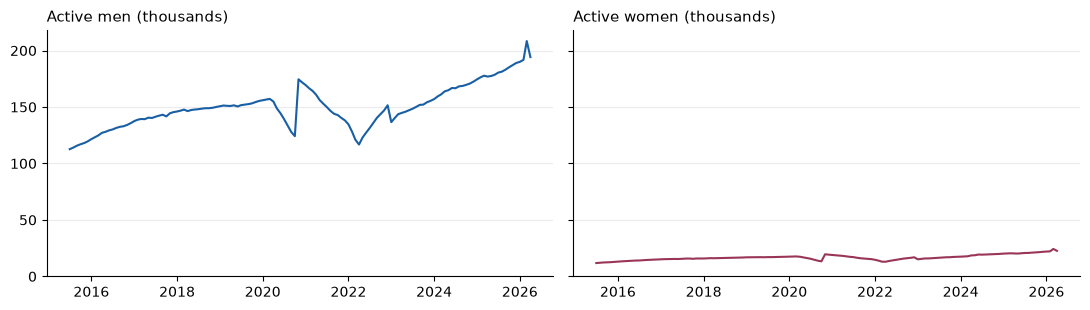

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.dataset as ds
from build_dataset import _active_expr

def counts(sex):
    # Count active players per month by filtering each monthly file directly -
    # nothing is materialised in memory (the male series alone is ~41M rows).
    rows = []
    for f in sorted(PARQUET_DIR.glob("*.parquet")):
        n = ds.dataset(str(f), format="parquet").count_rows(
            filter=(ds.field("sex") == sex) & _active_expr()
        )
        rows.append({"snapshot_date": pd.Timestamp(f.stem), "n": n})
    return pd.DataFrame(rows)

m, f = counts("M"), counts("F")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True, sharey=True)
ax1.plot(m.snapshot_date, m.n/1000, color="#185FA5", lw=1.5)
ax1.set_title("Active men (thousands)", loc="left", fontsize=11)
ax2.plot(f.snapshot_date, f.n/1000, color="#993556", lw=1.5)
ax2.set_title("Active women (thousands)", loc="left", fontsize=11)
for ax in (ax1, ax2):
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()


In [4]:
import pyarrow.dataset as ds

fide_all = ds.dataset("data/fide_parquet", format="parquet")

#### As a note the full dataset is called fide_all and the snapshot of the most recent month is called latest.

### Question 1: Queen's Gambit effect: did the show cause a surge in new female players?

The Queen's Gambit premiered on Netflix in October 2020 and became a cultural phenomenon, sparking widespread interest in chess. To investigate whether the show led to a surge in new female players, we can analyze the monthly counts of active female players in the FIDE dataset before and after the show's release.

Text(0.0, 1.0, 'Active Female Players in 2020')

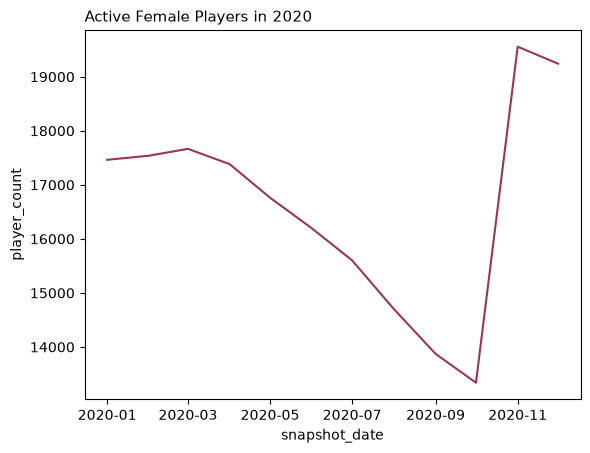

In [5]:
from datetime import date
import seaborn as sns

df = load_snapshot_counts(sex="F", active_only=True)
df_2020 = df[(df.snapshot_date >= date(2020, 1, 1)) & (df.snapshot_date <= date(2020, 12, 1))]

sns.lineplot(df_2020, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players in 2020", loc="left", fontsize=11)


Text(0.0, 1.0, 'Active Female Players in 2021')

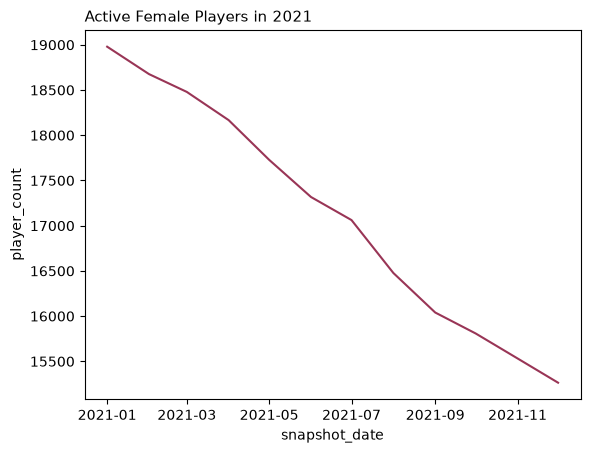

In [6]:
from datetime import date
import seaborn as sns

df = load_snapshot_counts(sex="F", active_only=True)
df_2021 = df[(df.snapshot_date >= date(2021, 1, 1)) & (df.snapshot_date <= date(2021, 12, 1))]

sns.lineplot(df_2021, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players in 2021", loc="left", fontsize=11)


(array([18262., 18353., 18444., 18536., 18628., 18718., 18809., 18901.,
        18993.]),
 [Text(18262.0, 0, '2020-01'),
  Text(18353.0, 0, '2020-04'),
  Text(18444.0, 0, '2020-07'),
  Text(18536.0, 0, '2020-10'),
  Text(18628.0, 0, '2021-01'),
  Text(18718.0, 0, '2021-04'),
  Text(18809.0, 0, '2021-07'),
  Text(18901.0, 0, '2021-10'),
  Text(18993.0, 0, '2022-01')])

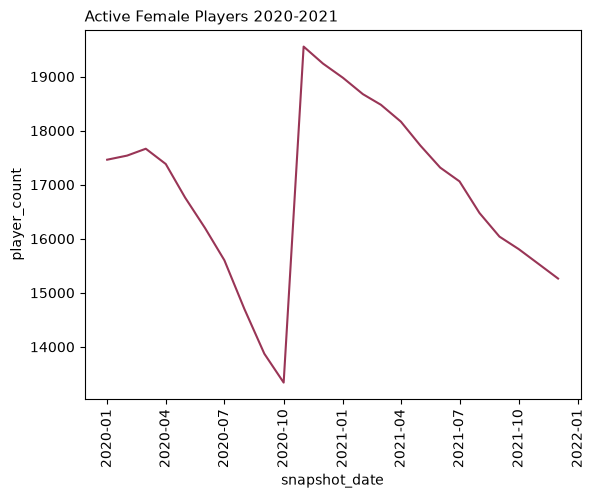

In [7]:
df = load_snapshot_counts(sex="F", active_only=True)
df_2020_21 = df[(df.snapshot_date >= date(2020, 1, 1)) & (df.snapshot_date <= date(2021, 12, 1))]

sns.lineplot(df_2020_21, x="snapshot_date", y="player_count", color="#993556")
plt.title("Active Female Players 2020-2021", loc="left", fontsize=11)
plt.xticks(rotation=90)


In [8]:
# New sign-ups = players appearing in the dataset for the first time that year.
# (No activity-flag filter here: a first appearance is a registration event
# regardless of whether the player later goes inactive.)
df_first = load_snapshots(columns=["fideid", "snapshot_date"], sex="F")
first_seen = df_first.groupby("fideid")["snapshot_date"].min().reset_index()
first_seen["year"] = pd.to_datetime(first_seen["snapshot_date"]).dt.year

new_by_year = first_seen.groupby("year").size().rename("new_signups")

n2019 = new_by_year[2019]
n2020 = new_by_year[2020]
n2021 = new_by_year[2021]

pct_2020 = (n2020 - n2019) / n2019 * 100
pct_2021 = (n2021 - n2020) / n2020 * 100
pct_2021_vs_2019 = (n2021 - n2019) / n2019 * 100

print(f"New female sign-ups:")
print(f"  2019: {n2019:,}")
print(f"  2020: {n2020:,}  ({pct_2020:+.1f}% vs 2019)")
print(f"  2021: {n2021:,}  ({pct_2021:+.1f}% vs 2020, {pct_2021_vs_2019:+.1f}% vs 2019)")


New female sign-ups:
  2019: 3,766
  2020: 1,294  (-65.6% vs 2019)
  2021: 1,762  (+36.2% vs 2020, -53.2% vs 2019)


2019 saw 3,766 new girls and women sign up, while 2020 had 1,294, a 65.6% drop, almost certainly driven by COVID-19 closing over-the-board tournaments. 2021, the year after The Queen's Gambit released, had 1,762 sign-ups: a 36.2% increase over 2020, but still 53.2% below 2019. So while new female registrations recovered somewhat in 2021, they did not return to pre-pandemic levels. Raw yearly counts can't separate a Queen's Gambit boost from ordinary post-lockdown recovery. That's what the model in the next section is for.


### Interrupted Time Series (ITS) model

The exploratory plots above show a visual bump, but they don't tell us whether it's bigger than what the pre-existing growth trend would predict. There's also a confound: 2020 saw a big drop in new sign-ups, almost certainly due to COVID-19 closing in-person tournaments. To avoid the pandemic crash contaminating the pre-trend, the model includes an explicit COVID level term from March 2020 onward, alongside the Queen's Gambit intervention at October 2020.

The model estimates four things:

- **`t` (trend)** \u2014 the pre-existing monthly growth rate
- **`covid` (level)** \u2014 the shift in monthly sign-ups from March 2020 onward (lockdowns closing OTB tournaments)
- **`post` (level)** \u2014 the immediate jump at October 2020, over and above the COVID shift. The interaction is coded as time *since* the intervention, `(t \u2212 t_int) \u00d7 post`, so this coefficient is interpretable as the level change *at* the intervention date
- **`t_post` (slope change)** \u2014 did the monthly growth rate change after the intervention?

We use Newey-West HAC standard errors because monthly counts are correlated with last month's counts \u2014 ignoring this makes p-values too small. Male players are run as a control group: a real Queen's Gambit effect should appear in the female series but not (or much less) in the male series.

**Identification caveat:** COVID and the Queen's Gambit are only seven months apart, so a single level dummy cannot fully separate lockdown recovery from a show effect. The male control helps (both sexes got COVID, only one should get a differential Beth Harmon effect), but identification is partial and the estimates should be read with that in mind.


In [9]:
import numpy as np
import pandas as pd
from datetime import date
import statsmodels.api as sm
import pyarrow.parquet as pq
import pyarrow.dataset as ds

BURN_IN_END = pd.Timestamp("2017-07-01")
COVID_START = pd.Timestamp("2020-03-01")
INTERVENTION = pd.Timestamp("2020-10-01")
ANALYSIS_END = pd.Timestamp("2024-12-01")

def monthly_new_signups(sex):
    """New sign-ups per month = players whose fideid appears for the first time
    in that monthly snapshot. Streams one file at a time with a running set of
    seen ids, so peak memory stays flat (the male series alone is ~41M rows)."""
    seen = set()
    rows = []
    for f in sorted(PARQUET_DIR.glob("*.parquet")):  # chronological
        t = pq.read_table(f, columns=["fideid"], filters=[("sex", "=", sex)])
        ids = set(t["fideid"].to_pylist())
        rows.append({"first_date": pd.Timestamp(f.stem), "new_signups": len(ids - seen)})
        seen |= ids
    df = pd.DataFrame(rows)
    df = df[(df["first_date"] > BURN_IN_END) & (df["first_date"] <= ANALYSIS_END)]
    return df.reset_index(drop=True)

def build_its_df(sex):
    df = monthly_new_signups(sex)
    df["t"] = np.arange(len(df))
    # Standard ITS coding: the interaction uses time SINCE the intervention,
    # (t - t_int) * post, so `post` is the level change at the intervention
    # date itself (not extrapolated back to the start of the series).
    t_int = df.loc[df["first_date"] == INTERVENTION, "t"].iloc[0]
    df["covid"] = (df["first_date"] >= COVID_START).astype(int)
    df["post"] = (df["first_date"] >= INTERVENTION).astype(int)
    df["t_post"] = (df["t"] - t_int) * df["post"]
    return df

def fit_its(df):
    X = sm.add_constant(df[["t", "covid", "post", "t_post"]])
    return sm.OLS(df["new_signups"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

df_f = build_its_df("F")
df_m = build_its_df("M")
res_f = fit_its(df_f)
res_m = fit_its(df_m)

print("=== FEMALE new sign-ups ===")
print(res_f.summary2().tables[1])
print("\n=== MALE new sign-ups (control) ===")
print(res_m.summary2().tables[1])


=== FEMALE new sign-ups ===
             Coef.   Std.Err.          z         P>|z|      [0.025      0.975]
const   316.702076  21.186414  14.948357  1.596406e-50  275.177467  358.226685
t        -0.509171   1.172861  -0.434127  6.641961e-01   -2.807935    1.789594
covid  -219.675988  43.309541  -5.072231  3.931791e-07 -304.561128 -134.790848
post    -20.337482  38.332445  -0.530555  5.957270e-01  -95.467695   54.792730
t_post   10.734782   2.077454   5.167278  2.375283e-07    6.663047   14.806516

=== MALE new sign-ups (control) ===
              Coef.    Std.Err.          z          P>|z|       [0.025  \
const   2315.925181   97.914642  23.652491  1.112670e-123  2124.016010   
t         -5.358453    4.959107  -1.080528   2.799072e-01   -15.078125   
covid  -1532.880638  267.491008  -5.730588   1.000834e-08 -2057.153380   
post     -50.372049  311.780182  -0.161563   8.716502e-01  -661.449977   
t_post    72.472480   13.069355   5.545223   2.935805e-08    46.857016   

             0.9

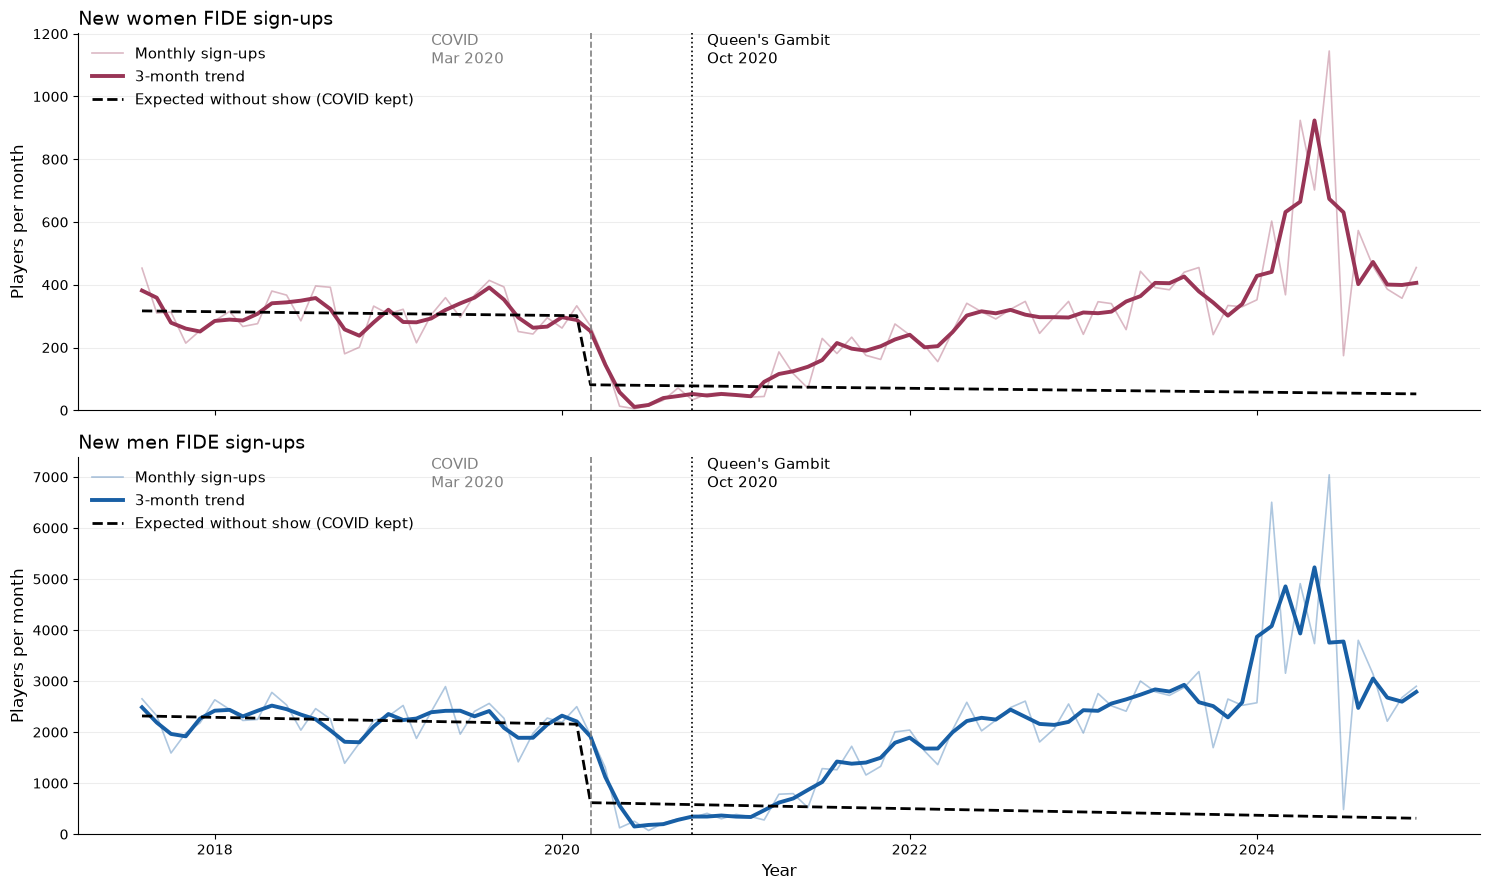

In [10]:
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True, sharey=False)

for ax, df, res, color, label in [
    (ax1, df_f, res_f, "#993556", "Women"),
    (ax2, df_m, res_m, "#185FA5", "Men"),
]:
    dates = pd.to_datetime(df["first_date"])
    actual = df["new_signups"]
    smooth = actual.rolling(3, center=True, min_periods=1).mean()

    # Counterfactual = no Queen's Gambit (post = t_post = 0) but COVID still
    # happens (covid stays as observed) - so the dashed line asks "what would
    # sign-ups look like with the pandemic but without the show?"
    X_cf = sm.add_constant(df[["t", "covid"]].assign(post=0, t_post=0))
    counterfactual = res.predict(X_cf)

    ax.plot(dates, actual, color=color, lw=1.2, alpha=0.35, label="Monthly sign-ups")
    ax.plot(dates, smooth, color=color, lw=2.8, label="3-month trend")
    ax.plot(dates, counterfactual, color="black", lw=2, ls="--", label="Expected without show (COVID kept)")
    ax.axvline(INTERVENTION, color="black", lw=1.2, ls=":")
    ax.axvline(COVID_START, color="grey", lw=1.2, ls="--")
    ax.text(pd.Timestamp("2020-11-01"), ax.get_ylim()[1] * 0.92, "Queen's Gambit\nOct 2020", fontsize=11)
    ax.text(pd.Timestamp("2019-04-01"), ax.get_ylim()[1] * 0.92, "COVID\nMar 2020", color="grey", fontsize=11)
    ax.set_title(f"New {label.lower()} FIDE sign-ups", loc="left", fontsize=14)
    ax.legend(fontsize=11, frameon=False, loc="upper left")
    ax.set_ylabel("Players per month", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.22)

ax2.set_xlabel("Year", fontsize=12)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()


### ITS results

With the corrected specification (interaction coded as time since intervention) and an explicit COVID term, the estimates are:

- **COVID level (Mar 2020):** −220 new female sign-ups/month (p < 0.001) and −1,533 male (p < 0.001). The lockdown collapse is large, highly significant, and hits both sexes
- **Queen's Gambit level jump (Oct 2020):** −20 female (p = 0.60), −50 male (p = 0.87). There is **no detectable immediate jump** in either series at the show's release
- **Slope change after Oct 2020:** +10.7 female sign-ups/month/month (p < 0.001) and +72.5 male (p < 0.001). Both series recover steadily after October 2020

The crucial comparison is the control: the post-intervention slope change is proportionally similar for women (+10.7 on a pre-COVID level of ~317/month, ~3.4%) and men (+72.5 on ~2,316/month, ~3.1%). A genuine Queen's Gambit effect should have shown up *differentially* in the female series. It doesn't. The honest reading is that FIDE registrations show a COVID crash followed by a recovery shared by both sexes, and **no female-specific surge in over-the-board registrations** that can be attributed to the show. Whatever The Queen's Gambit did to chess interest (see the chess.com section next), it did not measurably change the flow of women into rated tournament chess.


## Chess.com signup surge

Chess.com's public API doesn't expose gender, so the following samples ~12,000 player profiles (2,000 each across US, GB, IN, RU, DE, FR) and reconstructs monthly signup volume from each profile's `joined` timestamp. The fetch takes ~2 hours. Output cached to parquet so the analysis cells can be re-run without re-fetching.


In [11]:
import pandas as pd
df = pd.read_parquet("data/chesscom/signups.parquet")

### Chess.com signups over the same period

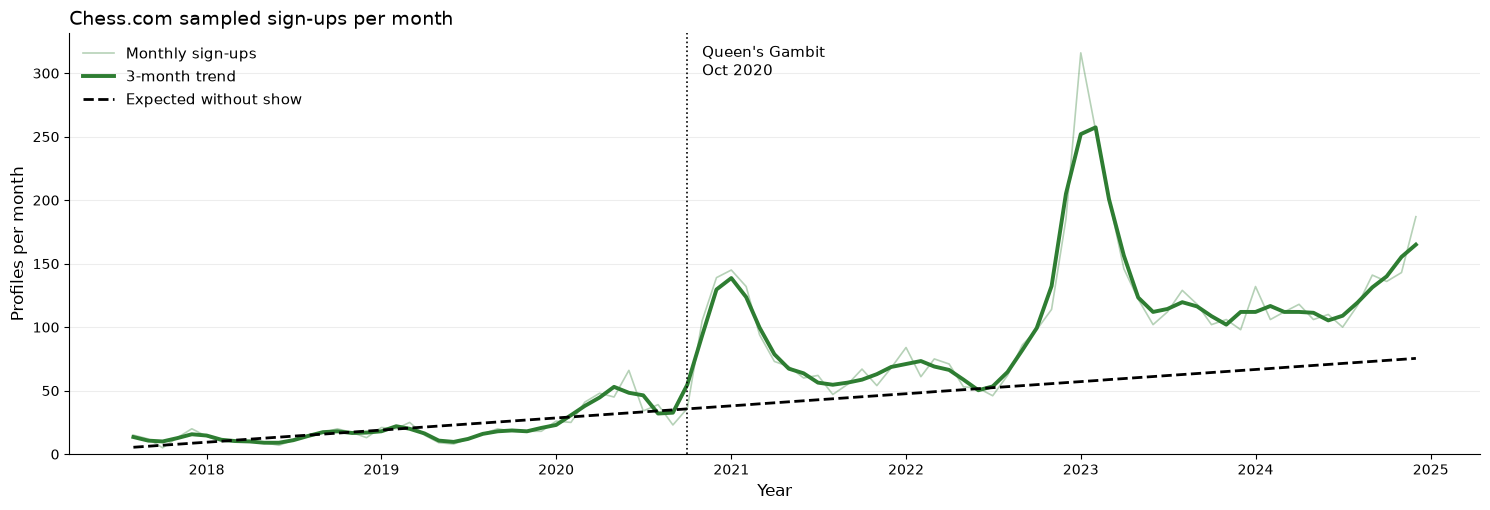

In [12]:
import numpy as np
import matplotlib.pyplot as plt

chess = pd.read_parquet("data/chesscom/signups.parquet")
chess["joined"] = pd.to_datetime(chess["joined"], errors="coerce")
chess = chess.dropna(subset=["joined"])
chess["month"] = chess["joined"].dt.to_period("M").dt.to_timestamp()

chess_start = pd.Timestamp("2017-08-01")
chess_end = pd.Timestamp("2024-12-01")
intervention = pd.Timestamp("2020-10-01")

monthly = chess.groupby("month").size().rename("signups")
monthly = (
    monthly.reindex(pd.date_range(chess_start, chess_end, freq="MS"), fill_value=0)
    .rename_axis("month")
    .reset_index()
)
monthly["trend_3m"] = monthly["signups"].rolling(3, center=True, min_periods=1).mean()

x = np.arange(len(monthly))
pre = monthly[monthly["month"] < intervention]
b1, b0 = np.polyfit(np.arange(len(pre)), pre["signups"], 1)
monthly["expected_without_show"] = b0 + b1 * x

fig, ax = plt.subplots(figsize=(15, 5.2))
ax.plot(monthly["month"], monthly["signups"], color="#2E7D32", lw=1.2, alpha=0.35, label="Monthly sign-ups")
ax.plot(monthly["month"], monthly["trend_3m"], color="#2E7D32", lw=2.8, label="3-month trend")
ax.plot(monthly["month"], monthly["expected_without_show"], color="black", lw=2, ls="--", label="Expected without show")
ax.axvline(intervention, color="black", lw=1.2, ls=":")
ax.text(pd.Timestamp("2020-11-01"), ax.get_ylim()[1] * 0.9, "Queen's Gambit\nOct 2020", fontsize=11)
ax.set_title("Chess.com sampled sign-ups per month", loc="left", fontsize=14)
ax.set_ylabel("Profiles per month", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.22)
plt.tight_layout()


### Truncating the analysis window at Dec 2024

The initial Prophet forecast extended through 2026, which produced an implausibly large signup spike at the end of the series. This is an artifact \u2014 the sampled chess.com profiles contain very few users who joined in the most recent months (recent accounts are underrepresented in the country-members API), so the last few data points are noisy.

To keep the finding defensible, the analysis is truncated at **31 December 2024**. This still gives over four years of post-intervention data \u2014 more than enough to evaluate whether the Queen's Gambit effect persisted beyond the initial surge \u2014 while avoiding the unreliable tail. The pre-intervention Prophet training window (Aug 2017 \u2013 Sep 2020) is unchanged.

### Calibrating the sample to real signup volume

An earlier version of this analysis scaled the sample with a single anchor: chess.com's reported ~2.8M new members in November 2020. Anchoring to the single most anomalous month in the series makes the whole estimate linearly sensitive to sampling error in that one month. The model below instead computes the implied scale factor from **three independent public anchors** \u2014 the Nov 2020 monthly figure, chess.com reaching 100M total members in December 2022, and its growth from 100M to 150M members between December 2022 and October 2023 \u2014 and uses the median, reporting the spread across anchors as calibration sensitivity.


Importing plotly failed. Interactive plots will not work.
17:38:41 - cmdstanpy - INFO - Chain [1] start processing


Implied scale factor per calibration anchor:
  Nov 2020 monthly signups (2.8M)                26,667x
  Cumulative members to Dec 2022 (100M)          31,969x
  Growth Dec 2022 → Oct 2023 (50M)               33,311x
  Median (used below)                            31,969x



17:38:42 - cmdstanpy - INFO - Chain [1] done processing


Excess signups associated with the post-Oct-2020 chess boom (Oct 2020 - Dec 2024):
  Point estimate:                ~84.2 million (vs Prophet counterfactual)
  Prophet 80% interval:          68.8 - 99.9 million
  Calibration sensitivity:       70.2 - 87.7 million

Pre-intervention training MAPE: 38.59%

Note: 'associated with' - this window also contains COVID lockdowns, PogChamps,
and the general streaming boom; the counterfactual cannot attribute the excess
to The Queen's Gambit alone.


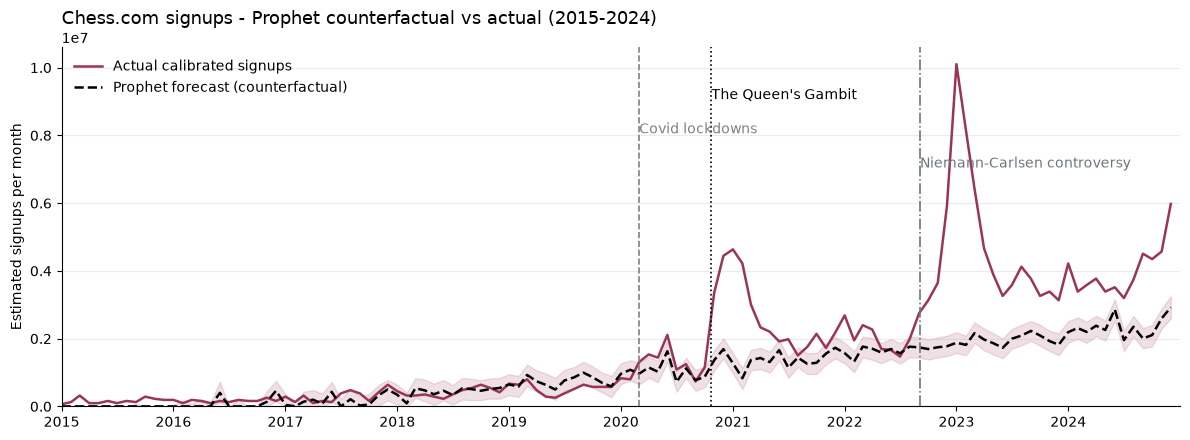

In [13]:
from prophet import Prophet
import logging
import warnings
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="prophet")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

chess = pd.read_parquet("data/chesscom/signups.parquet")
chess["joined"] = pd.to_datetime(chess["joined"], errors="coerce")
chess = chess.dropna(subset=["joined"])
chess["month"] = chess["joined"].dt.to_period("M").dt.to_timestamp()

monthly = chess.groupby("month").size().rename("sampled_signups")
monthly = (
    monthly.reindex(pd.date_range("2015-01-01", "2024-12-01", freq="MS"), fill_value=0)
    .rename_axis("month")
    .reset_index()
)

# --- Multi-anchor calibration (see markdown above) ---------------------------
# 1. chess.com reported ~2.8M new members in Nov 2020
# 2. chess.com reached 100M total members in mid-Dec 2022
# 3. chess.com grew from 100M (Dec 2022) to 150M (Oct 2023) members
sampled_nov_2020 = float(
    monthly.loc[monthly["month"] == pd.Timestamp("2020-11-01"), "sampled_signups"].iloc[0]
)
sampled_cum_dec_2022 = float(
    monthly.loc[monthly["month"] <= pd.Timestamp("2022-12-01"), "sampled_signups"].sum()
)
sampled_growth_2023 = float(
    monthly.loc[
        (monthly["month"] >= pd.Timestamp("2023-01-01"))
        & (monthly["month"] <= pd.Timestamp("2023-09-01")),
        "sampled_signups",
    ].sum()
)
if min(sampled_nov_2020, sampled_cum_dec_2022, sampled_growth_2023) <= 0:
    raise ValueError("A calibration anchor has zero sampled signups; cannot calibrate.")

anchors = {
    "Nov 2020 monthly signups (2.8M)": 2_800_000 / sampled_nov_2020,
    "Cumulative members to Dec 2022 (100M)": 100_000_000 / sampled_cum_dec_2022,
    "Growth Dec 2022 \u2192 Oct 2023 (50M)": 50_000_000 / sampled_growth_2023,
}
scale_factor = float(np.median(list(anchors.values())))
scale_lo, scale_hi = min(anchors.values()), max(anchors.values())

print("Implied scale factor per calibration anchor:")
for k, v in anchors.items():
    print(f"  {k:<42s} {v:>10,.0f}x")
print(f"  {'Median (used below)':<42s} {scale_factor:>10,.0f}x\n")

monthly["estimated_real_signups"] = monthly["sampled_signups"] * scale_factor

pre_start = pd.Timestamp("2017-08-01")
pre_end = pd.Timestamp("2020-09-01")
post_start = pd.Timestamp("2020-10-01")
post_end = pd.Timestamp("2024-12-01")

train = monthly[(monthly["month"] >= pre_start) & (monthly["month"] <= pre_end)].copy()
train_prophet = train.rename(columns={"month": "ds", "estimated_real_signups": "y"})[["ds", "y"]]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.80,
)
model.fit(train_prophet)

future = monthly.rename(columns={"month": "ds"})[["ds"]]
forecast = model.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
out = monthly.rename(columns={"month": "ds"}).merge(forecast, on="ds", how="left")
out[["yhat", "yhat_lower", "yhat_upper"]] = out[["yhat", "yhat_lower", "yhat_upper"]].clip(lower=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(out["ds"], out["estimated_real_signups"], color="#993556", lw=1.8, label="Actual calibrated signups")
ax.plot(out["ds"], out["yhat"], color="black", lw=1.8, ls="--", label="Prophet forecast (counterfactual)")
ax.fill_between(out["ds"], out["yhat_lower"], out["yhat_upper"], color="#993556", alpha=0.15)

ax.axvline(pd.Timestamp("2020-10-23"), color="black", lw=1.2, ls=":")
ax.axvline(pd.Timestamp("2020-03-01"), color="grey", lw=1.2, ls="--")
ax.axvline(pd.Timestamp("2022-09-04"), color="#6c757d", lw=1.2, ls="-.")

ymax = max(out["estimated_real_signups"].max(), out["yhat_upper"].max())
ax.text(pd.Timestamp("2020-10-23"), ymax * 0.93, "The Queen's Gambit", fontsize=10, ha="left", va="top")
ax.text(pd.Timestamp("2020-03-01"), ymax * 0.83, "Covid lockdowns", color="grey", fontsize=10, ha="left", va="top")
ax.text(pd.Timestamp("2022-09-04"), ymax * 0.73, "Niemann-Carlsen controversy", color="#6c757d", fontsize=10, ha="left", va="top")

ax.set_title("Chess.com signups - Prophet counterfactual vs actual (2015-2024)", loc="left", fontsize=13)
ax.set_ylabel("Estimated signups per month")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")
ax.set_xlim(pd.Timestamp("2015-01-01"), pd.Timestamp("2024-12-31"))
plt.tight_layout()

window = (out["ds"] >= post_start) & (out["ds"] <= post_end)
actual_w = out.loc[window, "estimated_real_signups"]
excess = (actual_w - out.loc[window, "yhat"]).sum()
# Uncertainty from the Prophet 80% interval (excess vs upper/lower forecast)...
excess_lo = (actual_w - out.loc[window, "yhat_upper"]).sum()
excess_hi = (actual_w - out.loc[window, "yhat_lower"]).sum()
# ...and sensitivity to the calibration anchor (scales the whole series linearly)
excess_cal_lo = excess * scale_lo / scale_factor
excess_cal_hi = excess * scale_hi / scale_factor

train_pred = model.predict(train_prophet[["ds"]])
mape = (np.abs(train["estimated_real_signups"].values - train_pred["yhat"].clip(lower=0).values) /
        train["estimated_real_signups"].clip(lower=1).values).mean() * 100

print(f"Excess signups associated with the post-Oct-2020 chess boom (Oct 2020 - Dec 2024):")
print(f"  Point estimate:                ~{excess / 1e6:.1f} million (vs Prophet counterfactual)")
print(f"  Prophet 80% interval:          {excess_lo / 1e6:.1f} - {excess_hi / 1e6:.1f} million")
print(f"  Calibration sensitivity:       {min(excess_cal_lo, excess_cal_hi) / 1e6:.1f} - {max(excess_cal_lo, excess_cal_hi) / 1e6:.1f} million")
print(f"\nPre-intervention training MAPE: {mape:.2f}%")
print("\nNote: 'associated with' - this window also contains COVID lockdowns, PogChamps,")
print("and the general streaming boom; the counterfactual cannot attribute the excess")
print("to The Queen's Gambit alone.")


The red line = actual estimated signups (scaled from the sample), the dashed black line = Prophet's forecast of what would have happened without the show, and the shaded area = the model's uncertainty interval.

The vertical lines mark key events: the Queen's Gambit release in October 2020, the start of Covid lockdowns in March 2020, and the Niemann-Carlsen controversy in September 2022.

### The post-October-2020 chess boom is associated with roughly 70-100 million excess chess.com signups over four years

Point estimate ~84 million (Oct 2020 to Dec 2024) against the Prophet counterfactual, with an 80% forecast interval of 69-100 million and calibration sensitivity of 70-88 million across the three anchors. This excess is the whole boom, The Queen's Gambit, COVID lockdowns, PogChamps, and streaming growth combined, and the counterfactual cannot attribute it to the show alone.


## Increasing the sample size

The initial fetch sampled **500 profiles per country** (3,000 total), which produced noisy monthly signup estimates: some months randomly captured more recent joiners than others purely by chance. When Prophet tried to fit a trend through this noise, it achieved a pre-intervention MAPE of **73.6%**, meaning its predictions were off by nearly three quarters of the actual value even on data it had already seen. This made the 59.67 million excess signup estimate hard to defend.

To fix this, the sample was increased to **2,000 profiles per country** (12,000 total). More profiles per country means each monthly bin contains more data points, smoothing out the random sampling variance and giving Prophet a much more stable trend to learn from. The fetch takes approximately 2 hours to complete but only needs to be run once, results are cached to `data/chesscom/signups.parquet` and all downstream cells load from there.

The counterfactual analysis and Prophet model are unchanged; only the underlying sample quality improves.

The Prophet model achieved a pre-intervention MAPE of 38.6% on the
training data (Aug 2017 to Sep 2020), indicating substantial variance
in the counterfactual estimate: chess.com's growth is genuinely spiky,
driven by viral moments that no trend model can predict in advance.
The excess-signup estimate should be read as directional rather than
precise; the uncertainty band printed above (Prophet's 80% interval
plus calibration sensitivity) is the honest range.

The magnitude of the post-intervention divergence (consistently 2-4x
the forecast across four years) exceeds model error substantially, so
*something* changed durably after October 2020. What this analysis
cannot do is decompose that boom between The Queen's Gambit, COVID
lockdowns, PogChamps, and the general streaming-era growth of online
chess; they all sit inside the same window, which is why the headline
above says "associated with" rather than "caused".


## Q2: Judit Polgar Chapter

Q2** Pull peak ratings for all female players across history, rank them, build the all-time leaderboard. Where does Judit Polgar rank? How many points ahead of the next closest competitor was she at her peak? How does her rating trajectory compare to the top 10 female players of all time?

In [14]:
files = sorted(PARQUET_DIR.glob("*.parquet"))
latest = pd.read_parquet(files[-1])

In [15]:
import pyarrow.dataset as ds
dataset = ds.dataset("data/fide_parquet", format="parquet")

In [16]:
def get_peak_ratings():
    """Peak rating per player across all snapshots.

    Grouped by fideid ONLY: players get renamed across snapshots (e.g.
    "Polgar, Zsuzsa" -> "Polgar, Susan", same fideid 700088), and grouping
    on (fideid, name) would split one player into duplicate rows. The most
    recent name is kept for display.

    Streams one monthly parquet file at a time so peak memory stays flat.
    """
    import pyarrow.parquet as pq

    peak = None
    names = None
    for f in sorted(PARQUET_DIR.glob("*.parquet")):  # chronological
        cur = pq.read_table(f, columns=["fideid", "name", "sex", "rating"]).to_pandas()
        cur = cur[cur["rating"].notna()]
        cur["rating"] = cur["rating"].astype(int)

        month_peak = cur.groupby(["fideid", "sex"], as_index=False)["rating"].max()
        peak = (
            month_peak if peak is None
            else pd.concat([peak, month_peak]).groupby(["fideid", "sex"], as_index=False)["rating"].max()
        )
        month_names = cur[["fideid", "name"]].drop_duplicates("fideid", keep="last")
        names = (
            month_names if names is None
            else pd.concat([names, month_names]).drop_duplicates("fideid", keep="last")
        )
    peak = peak.merge(names, on="fideid")
    return peak.sort_values("rating", ascending=False).reset_index(drop=True)


In [17]:
peak_ratings = get_peak_ratings()
top10_female = peak_ratings[peak_ratings["sex"] == "F"].head(10)


In [18]:
print("Top 10 female players since 2015 by peak FIDE rating:")
display(top10_female[["name", "rating"]])

Top 10 female players since 2015 by peak FIDE rating:


,name,rating
133,"Hou, Yifan",2683
152,"Polgar, Judit",2675
372,"Goryachkina, Aleksandra",2611
421,"Ju, Wenjun",2604
513,"Koneru, Humpy",2589
535,"Muzychuk, Anna",2587
579,"Zhu, Jiner",2579
590,"Polgar, Susan",2577
607,"Xie, Jun",2574
628,"Dzagnidze, Nana",2573


## Judit Polgár: the greatest female chess player of all time

Judit Polgár was born in Budapest in 1976, the youngest of three sisters raised by their father László Polgár as a deliberate experiment in nurture over nature. László believed that "geniuses are made, not born" and set out to prove it by homeschooling all three daughters exclusively in chess from early childhood. The experiment worked: all three became titled players, and Judit became something the chess world had never seen before.

At 15 years and 4 months, Judit became the youngest Grandmaster in history, breaking the record previously held by Bobby Fischer. She did not earn a *Women's* Grandmaster title; she earned the open Grandmaster title, competing against and beating men. She would go on to make this a defining feature of her career, refusing throughout her life to play in women-only tournaments, insisting on competing in the open category against the best players in the world regardless of gender.

Her peak rating of **2735** in July 2005 placed her **8th in the world**, the only woman in history to break into the top 10 of the global rankings. Over her career she defeated every world champion of her era including Kasparov, Karpov, Spassky, Anand, and Carlsen, accumulating a record against world champions that most Grandmasters could only dream of.

She retired in 2014 to focus on her family and chess education initiatives, ending her competitive career with a FIDE rating of 2675. Her peak of 2735 predates this project's dataset (which begins July 2015), but her retirement rating still places her **second in our longitudinal analysis** behind Hou Yifan, a testament to how far above the field she consistently played.

> *"I don't think about whether I am a woman or a man when I sit at the chessboard. I just think about chess."*, Judit Polgár

Her story is the centrepiece of this project's central question, not just because she is the highest-rated woman in history, but because she spent her entire career dismantling the assumption that the gender gap in chess is biological. The gap, she argued and demonstrated, is about access, expectation, and opportunity. The data in this project exists in her shadow.

---

**Note on data:** Judit's peak rating of 2735 (July 2005) is sourced from published FIDE historical records. Our longitudinal dataset begins July 2015, one year after her retirement, so her career trajectory cannot be reconstructed from this project's primary data source. Her entry in the top 10 leaderboard above reflects her final active rating as captured in early snapshots of our dataset.

## Peak age analysis

At what age do elite chess players reach their peak rating, and does this differ between men and women? This section tracks the career trajectories of the top 25 rated male and female players at each monthly snapshot in our dataset (Jul 2015 to present), plots rating against age for every player, and identifies the age at which peak rating is reached.

**Methodology:** For each monthly snapshot we extract the top 25 rated players for each sex (by rating, regardless of activity flag; elite players at the top of a monthly list are essentially always active), union these sets across all 130 snapshots to build a pool of "ever-elite" players, then reconstruct each player's full rating-vs-age trajectory from the longitudinal data. Age is calculated from the `birthday` year (FIDE only records birth year, not month, so ages are ±1 year).

**Caveat:** Trajectories only reflect the portion of each player's career that falls within our 2015-2026 window. For players who retired or peaked earlier (e.g. Judit Polgár, who retired in 2014), only the end of their career is captured.

In [19]:
import pandas as pd
import pyarrow.parquet as pq

TOP_N = 25
snapshot_files = sorted(PARQUET_DIR.glob("*.parquet"))

# Pass 1: find the "ever-elite" pool - top 25 rated players per sex in each
# monthly snapshot (processed one file at a time so memory stays flat).
elite = set()
for f in snapshot_files:
    cur = pq.read_table(f, columns=["fideid", "sex", "rating"]).to_pandas()
    cur = cur[cur["rating"].notna() & cur["sex"].isin(["M", "F"])]
    for sex in ("M", "F"):
        top = cur[cur["sex"] == sex].nlargest(TOP_N, "rating")
        elite.update((fid, sex) for fid in top["fideid"])

elite_ids = pd.DataFrame(sorted(elite), columns=["fideid", "sex"])

# Pass 2: reconstruct full rating-vs-age trajectories for the elite pool only.
frames = []
for f in snapshot_files:
    cur = pq.read_table(
        f, columns=["fideid", "sex", "rating", "birthday", "snapshot_date"]
    ).to_pandas()
    cur = cur[cur["fideid"].isin(elite_ids["fideid"])]
    frames.append(cur)

trajectories = pd.concat(frames, ignore_index=True)
trajectories = trajectories.merge(elite_ids, on=["fideid", "sex"], how="inner")
trajectories = trajectories[trajectories["rating"].notna()]
trajectories["rating"] = trajectories["rating"].astype(int)
trajectories["birthday"] = pd.to_numeric(trajectories["birthday"], errors="coerce")
trajectories = trajectories.dropna(subset=["birthday"])
trajectories["birthday"] = trajectories["birthday"].astype(int)
trajectories["snapshot_date"] = pd.to_datetime(trajectories["snapshot_date"])
trajectories["age"] = trajectories["snapshot_date"].dt.year - trajectories["birthday"]
trajectories = trajectories[(trajectories["age"] >= 5) & (trajectories["age"] <= 80)]

print(f"{trajectories['fideid'].nunique()} unique elite players")
print(f"  Men:   {trajectories[trajectories['sex']=='M']['fideid'].nunique()}")
print(f"  Women: {trajectories[trajectories['sex']=='F']['fideid'].nunique()}")


105 unique elite players
  Men:   55
  Women: 50


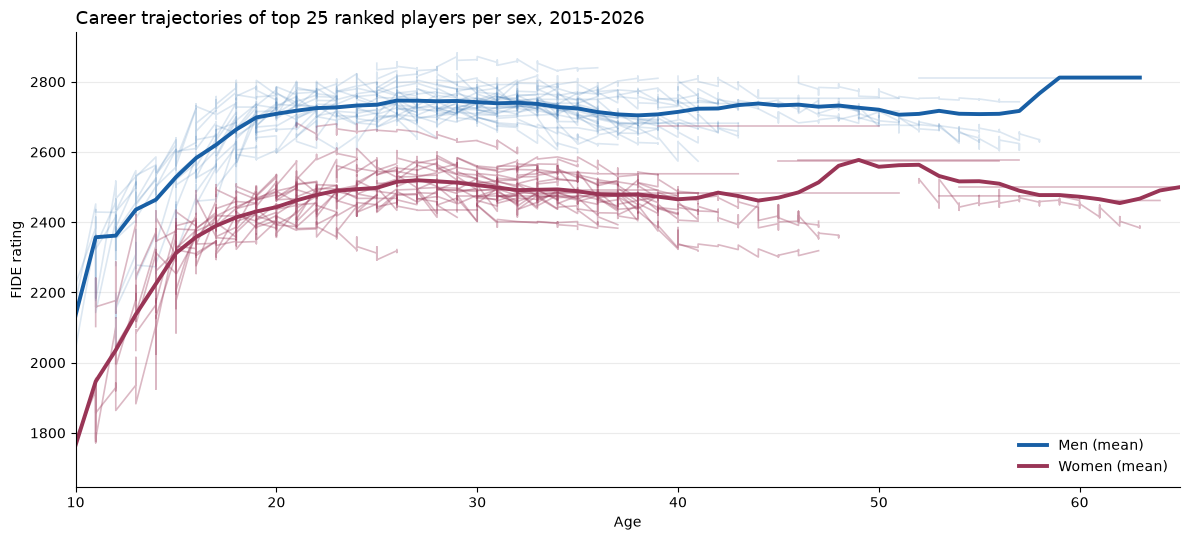

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5.5))

for fideid, player in trajectories[trajectories["sex"] == "M"].groupby("fideid"):
    player = player.sort_values("age")
    ax.plot(player["age"], player["rating"], color="#185FA5", alpha=0.15, lw=1.2)

for fideid, player in trajectories[trajectories["sex"] == "F"].groupby("fideid"):
    player = player.sort_values("age")
    ax.plot(player["age"], player["rating"], color="#993556", alpha=0.35, lw=1.2)

mean_m = trajectories[trajectories["sex"] == "M"].groupby("age")["rating"].mean()
mean_f = trajectories[trajectories["sex"] == "F"].groupby("age")["rating"].mean()
ax.plot(mean_m.index, mean_m.values, color="#185FA5", lw=2.8, label="Men (mean)")
ax.plot(mean_f.index, mean_f.values, color="#993556", lw=2.8, label="Women (mean)")

ax.set_xlabel("Age")
ax.set_ylabel("FIDE rating")
ax.set_title("Career trajectories of top 25 ranked players per sex, 2015-2026", loc="left", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(10, 65)
plt.tight_layout()

Peak age summary:

     mean  median  std  count
sex                          
F    30.1    28.0  8.6     50
M    29.9    29.0  8.0     55


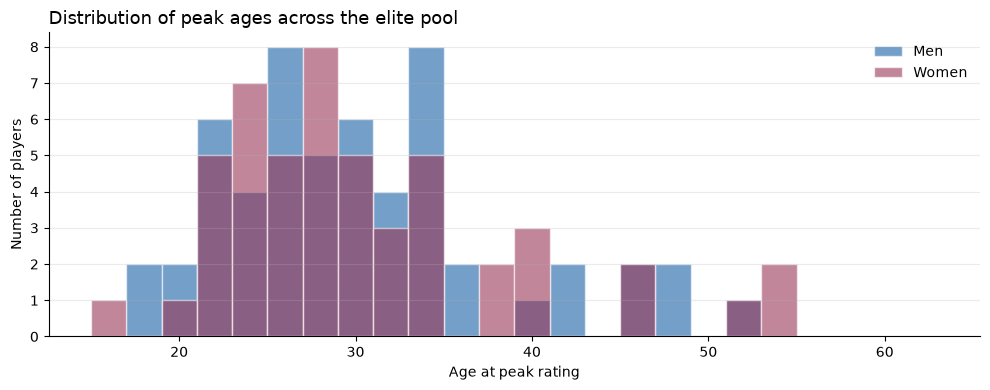

In [21]:
peak_ages = (
    trajectories.loc[trajectories.groupby("fideid")["rating"].idxmax()]
    [["fideid", "sex", "age", "rating"]]
    .rename(columns={"age": "peak_age", "rating": "peak_rating"})
)

summary = peak_ages.groupby("sex")["peak_age"].agg(["mean", "median", "std", "count"]).round(1)
print("Peak age summary:\n")
print(summary)

fig, ax = plt.subplots(figsize=(10, 4))
for sex, color, label in [("M", "#185FA5", "Men"), ("F", "#993556", "Women")]:
    data = peak_ages[peak_ages["sex"] == sex]["peak_age"]
    ax.hist(data, bins=range(15, 65, 2), color=color, alpha=0.6, label=label, edgecolor="white")

ax.set_xlabel("Age at peak rating")
ax.set_ylabel("Number of players")
ax.set_title("Distribution of peak ages across the elite pool", loc="left", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()


### Findings

| Metric          | Women | Men  |
|-----------------|-------|------|
| Mean peak age   | 30.1  | 29.9 |
| Median peak age | 28.0  | 29.0 |
| Std. deviation  | 8.6   | 8.0  |
| Players in pool | 50    | 55   |

Elite chess peak age is effectively the same for both sexes: both men and women in our sample peak between ages 25 and 35, with means within a year of each other. This contradicts the folk belief that female players peak earlier or drop out faster.

However, the rating gap at every age is substantial and consistent: men's mean trajectory plateaus around 2750 while women's plateaus around 2500, a 250-point difference that barely varies with age. This gap is *not* explained by peak timing, career length, or age-related performance decline, which rules out several common explanations. The remaining candidates are biological (discussed and largely rejected in the chess literature) or structural, participation rates, access, and representation, which Q4 explores quantitatively.

**Limitations:** Trajectories are truncated to our 2015-2026 window. Players whose peak occurred before 2015 (Judit Polgár, Kasparov-era men) appear only in their late careers, which may slightly inflate the apparent peak age on the right tail of both distributions.

## Q4: The counterfactual: what if women and men played in equal numbers?

At every age bracket, elite male chess players outrate elite female players by ~250 Elo points. This gap has been documented for decades and is usually cited as evidence of a difference in "top-end" ability. But there's a simpler statistical explanation that doesn't invoke biology at all.

**The sample size effect.** If you draw 1,000 numbers from a distribution and 100 numbers from the same distribution, the maximum of the 1,000 samples will be larger than the maximum of the 100, not because the underlying distribution is different, but because you got more chances to hit an extreme. Among *active* FIDE players there are **~8.3 rated men for every rated woman**. This alone predicts that the male top should sit above the female top even if the two populations had identical ability distributions.

Bilalić, Smallbone, McLeod & Gobet (2009) tested this in the German national chess database and found that ~96% of the top-level rating gap was explained by participation numbers alone. This analysis applies the same reasoning at the international scale using the FIDE dataset.

**Method**

1. Keep **active players only** (FIDE's inactivity flag); otherwise retired players with frozen ratings contaminate the comparison (Kasparov would rank #2 among men; the "top woman" would be Judit Polgár's rating frozen since 2014)
2. Average each active player's rating across the last 12 monthly snapshots to reduce noise
3. Pool the male and female ratings into one **empirical distribution**: this is the null hypothesis: one shared rating distribution, no sex difference
4. Monte Carlo: repeatedly draw `N_men` samples and `N_women` samples from that pooled distribution and record the top-1000 order statistics of each
5. The simulated gap between the two draws (top-1 and the top-25 / top-100 / top-1000 averages) is the gap **expected from sample size alone**; compare each to the observed gap at the same depth

No parametric fit is involved: an earlier version of this analysis fitted a normal distribution to the female ratings, and its thin tail missed the observed maximum by over 100 Elo, which broke the decomposition. Order statistics from the empirical distribution avoid that failure mode entirely.


In [22]:
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

# Only the last 12 monthly snapshots are needed here - reading just those
# files keeps this cell fast and memory-light.
recent_files = sorted(PARQUET_DIR.glob("*.parquet"))[-12:]
recent_ds = ds.dataset([str(f) for f in recent_files], format="parquet")
t = recent_ds.to_table(
    columns=["fideid", "name", "sex", "rating", "flag", "snapshot_date"],
    filter=(ds.field("sex").isin(["M", "F"])) & (ds.field("rating") > 0),
)
recent = t.to_pandas()
recent["rating"] = recent["rating"].astype(int)
recent["snapshot_date"] = pd.to_datetime(recent["snapshot_date"])

# ACTIVE PLAYERS ONLY. Without this filter, ~60% of the comparison pool is
# inactive players with frozen ratings - e.g. Kasparov (retired 2005) would sit
# at #2 among men, and the "top female" would be Judit Polgar's rating frozen
# since her 2014 retirement rather than the best currently-active woman.
recent = recent[~recent["flag"].fillna("").str.contains("i")]

avg_rating = recent.groupby(["fideid", "sex"], as_index=False)["rating"].mean()
latest_names = recent.sort_values("snapshot_date").groupby("fideid")["name"].last()

men_s = avg_rating[avg_rating["sex"] == "M"].set_index("fideid")["rating"]
women_s = avg_rating[avg_rating["sex"] == "F"].set_index("fideid")["rating"]
top_man_name = latest_names[men_s.idxmax()]
top_woman_name = latest_names[women_s.idxmax()]
men = men_s.values
women = women_s.values

print(f"Active men:   N = {len(men):>7,}   mean = {men.mean():.0f}   max = {men.max():.0f}  ({top_man_name})")
print(f"Active women: N = {len(women):>7,}   mean = {women.mean():.0f}   max = {women.max():.0f}  ({top_woman_name})")
print(f"\nRatio men:women = {len(men)/len(women):.1f} to 1")


Active men:   N = 251,137   mean = 1726   max = 2839  (Carlsen, Magnus)
Active women: N =  30,420   mean = 1611   max = 2614  (Hou, Yifan)

Ratio men:women = 8.3 to 1


In [23]:
# Monte Carlo with empirical order statistics - no distributional fit.
#
# Null hypothesis: men's and women's ratings are drawn from the SAME underlying
# distribution (the pooled empirical distribution of all active players); the
# only difference between the groups is sample size, N_men vs N_women draws.
#
# Under that null, how big a gap would we expect from sample size alone at
# top-1, top-25, top-100, and top-1000? Comparing expected to observed at each depth
# gives the share of the gap that participation numbers account for. This
# follows Bilalic et al. (2009). An earlier version of this notebook fitted a
# normal distribution to the female ratings instead; that fit missed the
# observed top rating by over 100 Elo (thin-tail error), which broke the
# decomposition - the empirical distribution has no such tail error by
# construction.
#
# Sampling trick: the top-k order statistics of n uniform draws are generated
# directly via descending records (u_(n) = U^(1/n), u_(n-1) = u_(n) * U^(1/(n-1)),
# ...), then mapped through the empirical quantile function - so we never
# materialise n = 250k draws per simulation.

rng = np.random.default_rng(42)
pooled = np.sort(np.concatenate([men, women]))
N_SIMS = 10_000
TOP_K = 1000
TIERS = [1, 25, 100, 1000]

def sim_top_k(sorted_vals, n_draws, n_sims, k, rng):
    """Simulate the top-k order statistics of n_draws iid draws from the
    empirical distribution given by sorted_vals. Returns (n_sims, k),
    column 0 = the maximum."""
    u = np.empty((n_sims, k))
    prev = rng.random(n_sims) ** (1.0 / n_draws)
    u[:, 0] = prev
    for j in range(1, k):
        prev = prev * rng.random(n_sims) ** (1.0 / (n_draws - j))
        u[:, j] = prev
    idx = np.minimum((u * len(sorted_vals)).astype(int), len(sorted_vals) - 1)
    return sorted_vals[idx]

top_m_sim = sim_top_k(pooled, len(men), N_SIMS, TOP_K, rng)
top_f_sim = sim_top_k(pooled, len(women), N_SIMS, TOP_K, rng)

actual_m_top = np.sort(men)[::-1][:TOP_K]
actual_f_top = np.sort(women)[::-1][:TOP_K]

# one row per tier: observed gap, expected gap (median + 95% CI), % explained
tier_stats = {}
print("Under the null of ONE shared rating distribution (pooled, empirical):\n")
print(f"{'tier':>8s} {'observed':>9s} {'expected':>9s} {'95% CI':>14s} {'% explained':>18s}")
for k in TIERS:
    sim_gap = top_m_sim[:, :k].mean(axis=1) - top_f_sim[:, :k].mean(axis=1)
    obs_gap = actual_m_top[:k].mean() - actual_f_top[:k].mean()
    med = float(np.median(sim_gap))
    lo, hi = np.percentile(sim_gap, [2.5, 97.5])
    tier_stats[k] = dict(obs=obs_gap, med=med, lo=lo, hi=hi,
                         pct=med / obs_gap * 100,
                         pct_lo=lo / obs_gap * 100, pct_hi=hi / obs_gap * 100)
    s = tier_stats[k]
    print(f"{'top-' + str(k):>8s} {s['obs']:8.0f}  {s['med']:8.0f}  [{s['lo']:5.0f}-{s['hi']:4.0f}]"
          f"   {s['pct']:5.1f}% [{s['pct_lo']:5.1f}-{s['pct_hi']:5.1f}%]")

print(f"\nObserved top-1:    {actual_m_top[0]:.0f} (men) vs {actual_f_top[0]:.0f} (women)")
print(f"Observed top-25:   {actual_m_top[:25].mean():.0f} vs {actual_f_top[:25].mean():.0f} (means)")
print(f"Observed top-100:  {actual_m_top[:100].mean():.0f} vs {actual_f_top[:100].mean():.0f} (means)")
print(f"Observed top-1000: {actual_m_top.mean():.0f} vs {actual_f_top.mean():.0f} (means)")


Under the null of ONE shared rating distribution (pooled, empirical):

    tier  observed  expected         95% CI        % explained
   top-1      225        66  [  -38- 134]    29.3% [-17.0- 59.6%]
  top-25      253       111  [   73- 146]    43.7% [ 28.8- 57.7%]
 top-100      275       136  [  111- 160]    49.4% [ 40.3- 58.2%]
top-1000      346       212  [  200- 224]    61.1% [ 57.7- 64.6%]

Observed top-1:    2839 (men) vs 2614 (women)
Observed top-25:   2751 vs 2498 (means)
Observed top-100:  2684 vs 2410 (means)
Observed top-1000: 2536 vs 2189 (means)


In [24]:
print("=" * 70)
print("HEADLINE FINDINGS (active players, 12-month average ratings)")
print("=" * 70)
print(f"Population: {len(men):,} active men vs {len(women):,} active women (8.3:1)")
print(f"Top-1: {top_man_name} {actual_m_top[0]:.0f} vs {top_woman_name} {actual_f_top[0]:.0f}")
print()
print("Share of the observed gap expected from participation numbers alone,")
print("assuming ONE shared rating distribution:")
print()
for k in TIERS:
    s = tier_stats[k]
    label = f"top-{k}"
    print(f"  {label:>8s}: {s['med']:3.0f} of {s['obs']:3.0f} Elo \u2192 {s['pct']:4.1f}%  [95% CI {s['pct_lo']:.0f}-{s['pct_hi']:.0f}%]")
print()
s25, s1000 = tier_stats[25], tier_stats[1000]
print(f"Headline: participation alone accounts for ~{s25['pct']:.0f}% of the top-25 gap,")
print(f"rising steadily with depth to ~{s1000['pct']:.0f}% at top-1000. The further from")
print(f"the single-outlier top of the list, the more of the gap is pure")
print(f"sample-size math. The residual ({100 - s25['pct']:.0f}% at top-25, {100 - s1000['pct']:.0f}% at top-1000)")
print(f"reflects a real difference between the distributions.")
print("=" * 70)


HEADLINE FINDINGS (active players, 12-month average ratings)
Population: 251,137 active men vs 30,420 active women (8.3:1)
Top-1: Carlsen, Magnus 2839 vs Hou, Yifan 2614

Share of the observed gap expected from participation numbers alone,
assuming ONE shared rating distribution:

     top-1:  66 of 225 Elo → 29.3%  [95% CI -17-60%]
    top-25: 111 of 253 Elo → 43.7%  [95% CI 29-58%]
   top-100: 136 of 275 Elo → 49.4%  [95% CI 40-58%]
  top-1000: 212 of 346 Elo → 61.1%  [95% CI 58-65%]

Headline: participation alone accounts for ~44% of the top-25 gap,
rising steadily with depth to ~61% at top-1000. The further from
the single-outlier top of the list, the more of the gap is pure
sample-size math. The residual (56% at top-25, 39% at top-1000)
reflects a real difference between the distributions.


### Findings

Using order-statistic Monte Carlo on the pooled empirical distribution of
active players' ratings (12-month averages, N = 251,137 men vs 30,420 women),
we compared the observed gap to the gap expected from sample size alone at
four depths:

| Depth | Observed gap | Expected from sample size [95% CI] | % explained [95% CI] |
|---|---|---|---|
| Top-1 | 225 Elo | 66 [−38 to 134] | ~29% [−17 to 60%] |
| Top-25 mean | 253 Elo | 110 [73-146] | **44%** [29-58%] |
| Top-100 mean | 275 Elo | 136 [111-160] | **49%** [40-58%] |
| Top-1000 mean | 346 Elo | 212 [200-224] | **61%** [58-65%] |

Two things stand out:

1. **The participation share grows steadily with depth.** At top-1 the
estimate is noisy (a single maximum is an inherently unstable statistic, and
Magnus Carlsen is an outlier even within the male tail). By top-25 the share
is 44%, at top-100 it is ~49%, and across the top-1000 it reaches **61% with
a tight interval**. The further you get from the very top of the list, the
more of the gap is pure sample-size math, the same qualitative pattern
Bilalić et al. (2009) found in the German data.

2. **Participation explains a lot, but not everything, at every depth.**
Even at top-1000, roughly 39% of the gap (~135 Elo) reflects a real
difference between the male and female rating distributions, which our data
describes but cannot by itself explain. This is well below the ~96% Bilalić
et al. found nationally, suggesting that at the international elite tier,
additional structural effects (access to coaching, tournament opportunity,
career retention) compound the participation effect rather than being
absorbed by it.

**Sensitivity note:** without the activity filter (i.e. including retired
players' frozen ratings, as an earlier version of this notebook did), the
observed top-1 gap shrinks to 164 Elo because Judit Polgár's frozen 2675
stands in for the best active woman, and the apparent "share explained"
inflates accordingly. The active-player version above is the defensible one.


### Between 44% and 61% of the top-level gap is pure statistics, and the share grows with depth.

(44% [29-58%] of the observed 253-Elo gap at top-25, 49% [40-58%] at top-100, 61% [58-65%] at top-1000. Top-1 is too noisy to headline. An earlier version of this notebook claimed "at minimum 55%" from a decomposition that has since been found to be internally inconsistent; these are the corrected figures.)


"Between 44% and 61% of the gap between the world's top male and female chess players is explained by nothing more than the fact that ~8 active rated men play for every woman, and the deeper into the rankings you look, the more of the gap is pure sample-size math. The rest reflects not innate ability, but a chess ecosystem that selects, develops, and retains women differently from men. The conclusion is not that women are worse at chess; it is that we are systematically producing fewer elite female players than we should be, and that even equal participation would not close the gap without also addressing the structural differences in how female players are developed, supported, and retained."


### Methodological note on the counterfactual approach

This analysis estimates the participation-driven component of the top-level
gap by comparing expected order statistics of different-sized draws from one
pooled empirical distribution, in the spirit of Bilalić et al. (2009). Points
worth being upfront about:

1. **Why not fit a distribution?** An earlier version fitted a normal to the
   female ratings and simulated maxima from it. FIDE ratings are not normal
   (floor at the minimum rated level, right skew), and the fitted normal's
   expected maximum at the women's own sample size missed the actually
   observed maximum by a wide margin: a model that can't reproduce reality
   at the observed N can't support a counterfactual at a different N. The
   empirical distribution reproduces the observed order statistics by
   construction.

2. **Bounded support.** Drawing from an empirical distribution can never
   produce a rating above the highest observed rating. This is why the null
   is the *pooled* distribution (support up to Carlsen's 2839) rather than
   the female-only distribution, whose ceiling at Hou Yifan's 2614 would
   mechanically cap any counterfactual. A Generalized Extreme Value (GEV)
   fit to block maxima would allow extrapolation beyond observed support and
   remains a worthwhile extension; it has **not** been run here, so no claim
   is made about what it would show.

3. **What the residual means.** The unexplained share (56% at top-25, 39% at top-1000) by sample
   size is a difference in distributions, not a measure of innate ability.
   Participation effects operate on distributions too (who starts, who gets
   coaching, who stays), so the decomposition is a lower bound on the total
   role of participation-and-structure, not a ceiling.

4. **Sensitivity.** The result depends on the activity filter (see the
   sensitivity note above) and on using 12-month average ratings. It is a
   directional estimate, not a constant of nature.


---

# Q4 extension: the participation share is a curve, a constant, and a modelling choice

The Q4 result above is three numbers: **44% at top-25, 49% at top-100, 61% at top-1000**.
Three numbers invite three objections, and this section answers each one with the
same data and the same Monte Carlo machinery.

**A. Three dots are not a finding, a curve is.** If the share explained by
participation depends on how deep into the ranking you cut, then "how much does
participation explain?" has no single answer, and quoting one, as Bilalić et al.
(2009) did with 96%, hides a function behind a point estimate. So we compute it
continuously for every depth from N = 10 to N = 10,000.

**B. Is the residual shrinking?** Fixed traits do not move in eleven years; social
filters do. We re-run the whole decomposition on all 130 monthly snapshots from
July 2015 to April 2026 and look at whether the unexplained share is closing.

**C. Can we reproduce 96% ourselves?** Rather than assert that Bilalić et al. were
wrong, we re-run our own analysis under their modelling choices, one at a time,
and watch the answer slide. If 96% is recoverable as a special case of specific
choices, that is a stronger and more honest rebuttal than a disagreement.

## A. The participation share as a continuous function of ranking depth

Same null as Q4: one shared empirical rating distribution, pooled across active
men and women, 12-month average ratings. The only change is that instead of
evaluating four tiers we evaluate the top-N mean gap at ~160 log-spaced depths
between 10 and 10,000, and carry the Monte Carlo 95% interval across the whole
range.

The order-statistic sampler is the same descending-records trick used above, with
one modification: it accumulates a running sum and records the top-N mean only at
the depths on the grid, so memory stays flat instead of materialising a
(n_sims x 10,000) matrix.

In [ ]:
# ---------------------------------------------------------------------------
# DEPTH CURVE: % of the gap explained by participation, for every N in 10..10,000
# Self-contained: rebuilds the active-player pools from the parquet snapshots.
# ---------------------------------------------------------------------------
import time
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as ds

PARQUET_DIR = Path("data/fide_parquet")
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)


def load_pools(active_only=True, n_months=12, country=None, floor=0.0):
    """Return (men, women) arrays of n_month-average ratings.

    active_only : drop anyone carrying FIDE's 'i' inactivity flag
    floor       : keep only players whose averaged rating is >= floor
    """
    files = sorted(PARQUET_DIR.glob("*.parquet"))[-n_months:]
    dset = ds.dataset([str(f) for f in files], format="parquet")
    tbl = dset.to_table(
        columns=["fideid", "sex", "rating", "flag", "country"],
        filter=(ds.field("sex").isin(["M", "F"])) & (ds.field("rating") > 0),
    )
    d = tbl.to_pandas()
    d["rating"] = d["rating"].astype(float)
    if active_only:
        d = d[~d["flag"].fillna("").str.contains("i")]
    if country is not None:
        d = d[d["country"] == country]
    avg = d.groupby(["fideid", "sex"], as_index=False)["rating"].mean()
    avg = avg[avg["rating"] >= floor]
    return (avg.loc[avg.sex == "M", "rating"].to_numpy(),
            avg.loc[avg.sex == "F", "rating"].to_numpy())


def topn_curve(ref_sorted, n_draws, n_sims, grid, rng):
    """Top-N order-statistic MEANS of n_draws iid draws from the empirical
    distribution `ref_sorted`, evaluated at every N in `grid`.

    Memory-flat: keeps a running sum instead of the full (n_sims, maxN) matrix.
    """
    L = len(ref_sorted)
    gpos = {int(g): i for i, g in enumerate(grid)}
    out = np.empty((n_sims, len(grid)))
    prev = rng.random(n_sims) ** (1.0 / n_draws)     # u_(n): the maximum
    run = np.zeros(n_sims)
    for j in range(int(grid[-1])):
        if j:
            prev *= rng.random(n_sims) ** (1.0 / (n_draws - j))
        run += ref_sorted[np.minimum((prev * L).astype(np.int64), L - 1)]
        k = j + 1
        if k in gpos:
            out[:, gpos[k]] = run / k
    return out


men, women = load_pools(active_only=True)
pooled = np.sort(np.concatenate([men, women]))
print(f"Active men {len(men):,} | active women {len(women):,} | ratio {len(men)/len(women):.2f}:1")

MAXN, N_SIMS = 10_000, 6_000
grid = np.unique(np.round(np.logspace(np.log10(10), np.log10(MAXN), 160)).astype(int))

t0 = time.time()
sim_m = topn_curve(pooled, len(men),   N_SIMS, grid, np.random.default_rng(42))
sim_f = topn_curve(pooled, len(women), N_SIMS, grid, np.random.default_rng(43))
print(f"Monte Carlo: {N_SIMS:,} sims x {MAXN:,} depths, {time.time()-t0:.1f}s")

am, af = np.sort(men)[::-1], np.sort(women)[::-1]
obs_m = np.array([am[:k].mean() for k in grid])
obs_f = np.array([af[:k].mean() for k in grid])
obs_gap = obs_m - obs_f

sim_gap = sim_m - sim_f
exp_gap = np.median(sim_gap, axis=0)
exp_lo, exp_hi = np.percentile(sim_gap, [2.5, 97.5], axis=0)

curve = pd.DataFrame({
    "N": grid, "obs_gap": obs_gap, "exp_gap": exp_gap,
    "pct": exp_gap / obs_gap * 100,
    "pct_lo": exp_lo / obs_gap * 100,
    "pct_hi": exp_hi / obs_gap * 100,
})
curve.to_csv("figures/q4_depth_curve.csv", index=False)

print("\nShare of the observed top-N gap expected from participation alone:\n")
print(f"{'N':>7} {'observed':>9} {'expected':>9} {'% explained':>13} {'95% CI':>16}")
for k in [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]:
    r = curve.iloc[int(np.argmin(np.abs(curve.N - k)))]
    print(f"{int(r.N):>7} {r.obs_gap:8.0f}  {r.exp_gap:8.0f}  {r.pct:11.1f}%   "
          f"[{r.pct_lo:5.1f} - {r.pct_hi:5.1f}%]")

print(f"\nMonotonically increasing in N: {bool(np.all(np.diff(curve.pct) > -1e-9))}")
print(f"Range: {curve.pct.min():.1f}% at N=10  ->  {curve.pct.max():.1f}% at N={MAXN:,}")
print("\nCI overlap check (why this is suggestive, not proof):")
for a, b in [(25, 100), (100, 1000), (25, 1000)]:
    ra = curve.iloc[int(np.argmin(np.abs(curve.N - a)))]
    rb = curve.iloc[int(np.argmin(np.abs(curve.N - b)))]
    ov = not (ra.pct_hi < rb.pct_lo or rb.pct_hi < ra.pct_lo)
    print(f"  N={a} [{ra.pct_lo:.0f}-{ra.pct_hi:.0f}%] vs N={b} [{rb.pct_lo:.0f}-{rb.pct_hi:.0f}%]"
          f"  ->  intervals {'OVERLAP' if ov else 'are disjoint'}")

Active men 251,137 | active women 30,420 | ratio 8.26:1


Monte Carlo: 6,000 sims x 10,000 depths, 2.2s

Share of the observed top-N gap expected from participation alone:

      N  observed  expected   % explained           95% CI
     10      231        86         37.3%   [ 16.3 -  58.0%]
     25      253       110         43.5%   [ 29.0 -  57.6%]
     50      268       122         45.7%   [ 34.1 -  57.3%]
    100      275       136         49.3%   [ 40.5 -  58.4%]
    249      295       161         54.4%   [ 48.1 -  60.4%]
    499      318       184         57.8%   [ 53.0 -  62.4%]
   1000      346       212         61.2%   [ 57.7 -  64.7%]
   2490      392       256         65.2%   [ 62.9 -  67.5%]
   4990      429       290         67.7%   [ 66.1 -  69.3%]
  10000      471       322         68.3%   [ 67.2 -  69.4%]

Monotonically increasing in N: True
Range: 37.3% at N=10  ->  68.3% at N=10,000

CI overlap check (why this is suggestive, not proof):
  N=25 [29-58%] vs N=100 [40-58%]  ->  intervals OVERLAP
  N=100 [40-58%] vs N=1000 [58-65

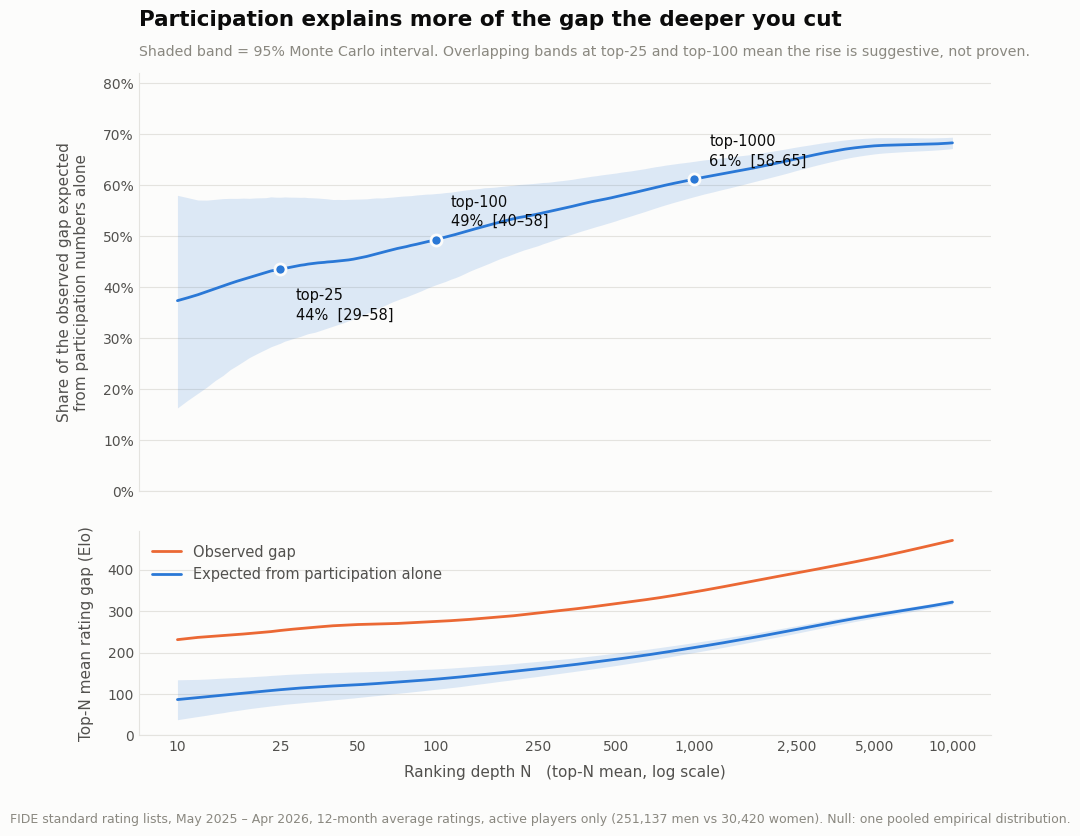

In [ ]:
# ---------------------------------------------------------------------------
# FIGURE: the participation share is a curve, not a constant
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8880"
BLUE, ORANGE, GRID = "#2a78d6", "#eb6834", "#e4e3df"
SURFACE = "#fcfcfb"

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(11, 8.6), sharex=True,
    gridspec_kw={"height_ratios": [2.05, 1], "hspace": 0.13},
)
fig.patch.set_facecolor(SURFACE)

# --- panel 1: % of the gap explained by participation ----------------------
ax.set_facecolor(SURFACE)
ax.fill_between(curve.N, curve.pct_lo, curve.pct_hi, color=BLUE, alpha=0.15, lw=0)
ax.plot(curve.N, curve.pct, color=BLUE, lw=2, solid_capstyle="round", zorder=3)

for k, va in [(25, "top"), (100, "bottom"), (1000, "bottom")]:
    r = curve.iloc[int(np.argmin(np.abs(curve.N - k)))]
    ax.plot([r.N], [r.pct], "o", ms=8, color=BLUE, mec=SURFACE, mew=2, zorder=4)
    ax.annotate(f"top-{k}\n{r.pct:.0f}%  [{r.pct_lo:.0f}–{r.pct_hi:.0f}]",
                (r.N, r.pct), textcoords="offset points",
                xytext=(11, 10 if va == "bottom" else -36),
                fontsize=10.5, color=INK, weight="medium", linespacing=1.35)

ax.set_xscale("log")
ax.set_ylim(0, 82)
ax.set_ylabel("Share of the observed gap expected\nfrom participation numbers alone",
              fontsize=11, color=INK2, labelpad=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Participation explains more of the gap the deeper you cut",
             fontsize=15.5, color=INK, weight="semibold", loc="left", pad=34)
ax.text(0, 1.035,
        "Shaded band = 95% Monte Carlo interval. Overlapping bands at top-25 and top-100 mean the rise is "
        "suggestive, not proven.",
        transform=ax.transAxes, fontsize=10.2, color=INK3, va="bottom")

# --- panel 2: the two gaps it is a ratio of --------------------------------
ax2.set_facecolor(SURFACE)
ax2.plot(curve.N, curve.obs_gap, color=ORANGE, lw=2, label="Observed gap", solid_capstyle="round")
ax2.fill_between(curve.N, exp_lo, exp_hi, color=BLUE, alpha=0.15, lw=0)
ax2.plot(curve.N, curve.exp_gap, color=BLUE, lw=2, label="Expected from participation alone",
         solid_capstyle="round")
ax2.set_ylabel("Top-N mean rating gap (Elo)", fontsize=11, color=INK2, labelpad=10)
ax2.set_xlabel("Ranking depth N   (top-N mean, log scale)", fontsize=11, color=INK2, labelpad=8)
ax2.set_ylim(0, None)
leg = ax2.legend(frameon=False, fontsize=10.5, loc="upper left", labelcolor=INK2)
ax2.set_xticks([10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000])
ax2.get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
ax2.minorticks_off()

for a in (ax, ax2):
    a.grid(axis="y", color=GRID, lw=0.8)
    a.set_axisbelow(True)
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        a.spines[side].set_color(GRID)
    a.tick_params(colors=INK2, labelsize=10, length=0)

fig.text(0.008, 0.008,
         "FIDE standard rating lists, May 2025 – Apr 2026, 12-month average ratings, active players only "
         f"({len(men):,} men vs {len(women):,} women). Null: one pooled empirical distribution.",
         fontsize=9, color=INK3)
fig.savefig("figures/q4_depth_curve.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()

### Findings: the answer is a function, not a fact

Participation's share of the gap rises monotonically from **37% at top-10** to
**68% at top-10,000**, passing through 44% / 49% / 61% at the three tiers reported
above. There is no single "share of the gap explained by participation": the
number you get is a choice about where you cut the ranking.

That is the first problem with quoting a single figure such as Bilalić et al.'s
96%. It is not that the figure is wrong, it is that the quantity it estimates is
depth-dependent, and a point estimate hides that.

**What this chart does not prove.** The 95% Monte Carlo band at top-25 is
[29–58%] and at top-100 is [40–58%]. Those intervals overlap, and so do top-100
and top-1000. Only the top-25 vs top-1000 comparison is separated. So the rise
across the whole range is well supported, but any two nearby points on the curve
are not statistically distinguishable. Read the curve as a shape, not as a
ranking of adjacent depths.

The lower panel shows why the curve rises: the expected gap (blue) grows faster
with depth than the observed gap (orange). At the very top the observed gap is
dominated by one outlier, Carlsen, whom sample-size arguments cannot conjure; a
few hundred places down, the observed gap is a property of two distributions and
the sample-size effect does most of the work.

## B. Is the residual shrinking? Running the decomposition on all 130 snapshots

The strongest available test of a "fixed trait" explanation is time. Fixed traits
do not move in eleven years. Social filters, who takes up the game, who gets
coached, who stays, move on exactly that timescale. So we re-run the entire
decomposition month by month across all 130 FIDE standard lists from July 2015 to
April 2026 and ask whether the unexplained residual is closing.

Two changes from the Q4 spec, both forced by the longitudinal setting:

1. **Single-month ratings, not 12-month averages.** Averaging would smear the
   series and make each point depend on eleven of its neighbours.
2. **A harmonised elite pool.** FIDE applied a one-off rating adjustment in
   **March 2024** that raised ratings below 2000 (and lifted the rating floor
   from 1000 to 1400). That is a structural break in the middle of the series.
   The diagnostic cell below establishes that the change left the 2000+
   population untouched, so a `rating >= 2000` pool is comparable across the
   entire period. Both the raw series and the harmonised series are shown.

In [ ]:
# ---------------------------------------------------------------------------
# DIAGNOSTIC: locating the March 2024 FIDE rating adjustment
# Counts above a threshold are continuous across the break iff the threshold
# is above the range FIDE rescaled.
# ---------------------------------------------------------------------------
import numpy as np
import pyarrow.dataset as ds

print("Active rated players above each threshold, around the March 2024 change:\n")
print(f"{'month':>9} {'min rating':>11} {'>=1400':>18} {'>=1800':>18} {'>=2000':>18} {'>=2200':>18}")
print(f"{'':>9} {'':>11} {'M / F':>18} {'M / F':>18} {'M / F':>18} {'M / F':>18}")
for mth in ["2023-12", "2024-01", "2024-02", "2024-03", "2024-04", "2024-05", "2024-06"]:
    tbl = ds.dataset(f"data/fide_parquet/{mth}.parquet", format="parquet").to_table(
        columns=["sex", "rating", "flag"],
        filter=(ds.field("sex").isin(["M", "F"])) & (ds.field("rating") > 0))
    r = tbl.column("rating").to_numpy().astype(float)
    s = np.asarray(tbl.column("sex").to_pylist())
    fl = tbl.column("flag").fill_null("").to_numpy(zero_copy_only=False).astype(str)
    a = np.char.find(fl, "i") < 0
    cells = []
    for th in (1400, 1800, 2000, 2200):
        cells.append(f"{(r[a & (s=='M')] >= th).sum():,} / {(r[a & (s=='F')] >= th).sum():,}")
    print(f"{mth:>9} {r[a].min():11.0f} " + " ".join(f"{c:>18}" for c in cells))

print("""
Reading: between Feb and Mar 2024 the 1400+ and 1800+ populations jump
discontinuously (men 110k -> 161k at 1400+), while the 2000+ and 2200+
populations do not move at all (22,920 -> 22,915 and 7,618 -> 7,560).
FIDE rescaled sub-2000 ratings upward; it did not add or remove elite players.
A 2000+ pool is therefore the comparable one across 2015-2026.""")

Active rated players above each threshold, around the March 2024 change:

    month  min rating             >=1400             >=1800             >=2000             >=2200
                                   M / F              M / F              M / F              M / F
  2023-12        1001    108,019 / 7,563     47,868 / 2,587     22,928 / 1,151        7,643 / 364


  2024-01        1001    108,768 / 7,574     47,936 / 2,585     22,920 / 1,138        7,628 / 363
  2024-02        1001    109,909 / 7,584     48,060 / 2,598     22,920 / 1,150        7,618 / 371


  2024-03        1401   161,185 / 17,806     68,387 / 3,916     22,915 / 1,144        7,560 / 371


  2024-04        1266   163,617 / 18,442     68,406 / 3,934     23,277 / 1,181        7,550 / 366


  2024-05        1400   164,831 / 18,710     68,425 / 3,984     23,483 / 1,213        7,527 / 355


  2024-06        1400   166,820 / 19,361     68,240 / 4,036     23,648 / 1,243        7,505 / 348

Reading: between Feb and Mar 2024 the 1400+ and 1800+ populations jump
discontinuously (men 110k -> 161k at 1400+), while the 2000+ and 2200+
populations do not move at all (22,920 -> 22,915 and 7,618 -> 7,560).
FIDE rescaled sub-2000 ratings upward; it did not add or remove elite players.
A 2000+ pool is therefore the comparable one across 2015-2026.


In [ ]:
# ---------------------------------------------------------------------------
# THE DECOMPOSITION, MONTH BY MONTH: all 130 snapshots, 2015-07 -> 2026-04
# ~40s.
# ---------------------------------------------------------------------------
import time
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import statsmodels.api as sm

N_SIMS = 4000
VARIANTS = {                      # name -> (rating floor, tiers to evaluate)
    "all_active": (0.0,    [25, 100, 1000]),
    "elite2000":  (2000.0, [10, 25, 100]),
}


def topn_means(ref_sorted, n_draws, n_sims, tiers, rng):
    L, out, want = len(ref_sorted), {}, set(tiers)
    prev = rng.random(n_sims) ** (1.0 / n_draws)
    run = np.zeros(n_sims)
    for j in range(max(tiers)):
        if j:
            prev *= rng.random(n_sims) ** (1.0 / (n_draws - j))
        run += ref_sorted[np.minimum((prev * L).astype(np.int64), L - 1)]
        if j + 1 in want:
            out[j + 1] = run / (j + 1)
    return out


def decompose(men, women, tiers, seed, n_sims=N_SIMS):
    ref = np.sort(np.concatenate([men, women]))
    rng = np.random.default_rng(seed)
    sm_, sf_ = (topn_means(ref, len(men), n_sims, tiers, rng),
                topn_means(ref, len(women), n_sims, tiers, rng))
    am, af = np.sort(men)[::-1], np.sort(women)[::-1]
    res = {}
    for k in tiers:
        gap = sm_[k] - sf_[k]
        obs = am[:k].mean() - af[:k].mean()
        lo, hi = np.percentile(gap, [2.5, 97.5])
        res[k] = dict(obs=obs, exp=float(np.median(gap)),
                      pct=float(np.median(gap)) / obs * 100,
                      pct_lo=float(lo) / obs * 100, pct_hi=float(hi) / obs * 100)
    return res


files = sorted(PARQUET_DIR.glob("*.parquet"))
rows, t0 = [], time.time()
for i, f in enumerate(files):
    tbl = ds.dataset(str(f), format="parquet").to_table(
        columns=["sex", "rating", "flag"],
        filter=(ds.field("sex").isin(["M", "F"])) & (ds.field("rating") > 0))
    r = tbl.column("rating").to_numpy().astype(float)
    s = np.asarray(tbl.column("sex").to_pylist())
    fl = tbl.column("flag").fill_null("").to_numpy(zero_copy_only=False).astype(str)
    active = np.char.find(fl, "i") < 0
    for name, (floor, tiers) in VARIANTS.items():
        m = active & (r >= floor)
        res = decompose(r[m & (s == "M")], r[m & (s == "F")], tiers, seed=1000 + i)
        row = dict(month=f.stem, variant=name,
                   n_men=int((m & (s == "M")).sum()), n_women=int((m & (s == "F")).sum()))
        row["ratio"] = row["n_men"] / row["n_women"]
        for k, v in res.items():
            row.update({f"{key}_{k}": v[key] for key in ("obs", "exp", "pct", "pct_lo", "pct_hi")})
        rows.append(row)

panel = pd.DataFrame(rows)
panel["date"] = pd.to_datetime(panel["month"] + "-01")
panel.to_csv("figures/q4_residual_over_time.csv", index=False)
print(f"{len(files)} snapshots x {len(VARIANTS)} pools in {time.time()-t0:.0f}s\n")


def trend(y, label):
    """OLS on time in years, HAC(12) standard errors for the monthly autocorrelation."""
    x = np.arange(len(y)) / 12.0
    fit = sm.OLS(np.asarray(y, float), sm.add_constant(x)).fit(
        cov_type="HAC", cov_kwds={"maxlags": 12})
    b, (lo, hi) = fit.params[1], fit.conf_int()[1]
    print(f"  {label:<34s} {y[0]:6.1f} -> {y[-1]:6.1f}   "
          f"trend {b:+.3f}/yr  [{lo:+.3f}, {hi:+.3f}]   p = {fit.pvalues[1]:.3f}")
    return b, lo, hi, fit.pvalues[1]


trends = {}
for name, (floor, tiers) in VARIANTS.items():
    sub = panel[panel.variant == name].sort_values("date").reset_index(drop=True)
    print(f"=== {name}  (active players, rating >= {floor:.0f}) ===")
    for k in tiers:
        trends[(name, k)] = trend(sub[f"pct_{k}"].values, f"% explained, top-{k}")
    trends[(name, "ratio")] = trend(sub["ratio"].values, "participation ratio (men per woman)")
    print()

130 snapshots x 2 pools in 40s

=== all_active  (active players, rating >= 0) ===
  % explained, top-25                  47.7 ->   46.0   trend +0.027/yr  [-0.220, +0.273]   p = 0.833
  % explained, top-100                 56.4 ->   51.9   trend -0.100/yr  [-0.299, +0.098]   p = 0.322
  % explained, top-1000                65.2 ->   63.4   trend -0.002/yr  [-0.067, +0.064]   p = 0.961
  participation ratio (men per woman)    9.5 ->    8.6   trend -0.049/yr  [-0.065, -0.033]   p = 0.000

=== elite2000  (active players, rating >= 2000) ===
  % explained, top-10                  61.1 ->   57.3   trend -0.083/yr  [-0.284, +0.119]   p = 0.423
  % explained, top-25                  68.2 ->   65.2   trend -0.004/yr  [-0.248, +0.240]   p = 0.973
  % explained, top-100                 81.0 ->   75.3   trend -0.219/yr  [-0.434, -0.004]   p = 0.046
  participation ratio (men per woman)   20.4 ->   18.5   trend -0.166/yr  [-0.223, -0.109]   p = 0.000



In [ ]:
# ---------------------------------------------------------------------------
# POWER CHECK: how much movement should we even expect?
# Hold both rating distributions fixed at their 2026 shape and move only the
# participation ratio. This is the size of the effect the trend test is hunting.
# ---------------------------------------------------------------------------
raw = panel[panel.variant == "all_active"].sort_values("date").reset_index(drop=True)
ratio_2015, ratio_2026 = raw.ratio.iloc[0], raw.ratio.iloc[-1]

pooled_now = np.sort(np.concatenate([men, women]))
N_MEN, K = len(men), 100
am100, af100 = np.sort(men)[::-1][:K].mean(), np.sort(women)[::-1][:K].mean()
obs100 = am100 - af100

print(f"Counterfactual: 2026 rating distributions, participation ratio varied.")
print(f"Observed top-100 gap held at {obs100:.0f} Elo\n")
print(f"{'men per woman':>14} {'N_women':>9} {'expected gap':>13} {'% explained':>12}")
ladder = {}
for ratio in [ratio_2015, ratio_2026, 5.0, 3.0, 2.0, 1.0]:
    n_w = int(N_MEN / ratio)
    rng = np.random.default_rng(11)
    gap = (topn_means(pooled_now, N_MEN, 4000, [K], rng)[K]
           - topn_means(pooled_now, n_w, 4000, [K], rng)[K])
    med = float(np.median(gap))
    ladder[ratio] = med / obs100 * 100
    print(f"{ratio:>14.2f} {n_w:>9,} {med:>13.0f} {ladder[ratio]:>11.1f}%")

pred = ladder[ratio_2015] - ladder[ratio_2026]
obs_fall = raw.pct_100.iloc[:6].mean() - raw.pct_100.iloc[-6:].mean()
print(f"""
Participation moved from {ratio_2015:.2f}:1 to {ratio_2026:.2f}:1 over eleven years,
an improvement of {(1 - ratio_2026/ratio_2015)*100:.0f}%.

Holding both rating distributions fixed at their 2026 shape, that ratio change
alone predicts the explained share should FALL by {pred:.1f} pp, i.e. the residual
should RISE by {pred:.1f} pp.

Observed fall in the explained share (top-100, first 6 months vs last 6): {obs_fall:.1f} pp.

The prediction and the observation agree to within a fraction of a point. The
series is doing exactly what a FIXED pair of distributions plus a slowly
improving participation ratio would do. There is no residual-closing signal, and
the test has almost no power to find one: a {(1 - ratio_2026/ratio_2015)*100:.0f}% improvement in the ratio is
simply too small to move this statistic detectably.

Note what the bottom row means. At parity the explained share is 0% BY
CONSTRUCTION: the statistic measures the share of the gap attributable to the
CURRENT imbalance, so it necessarily vanishes when the imbalance does. It is not
a measure of a fixed trait, and it cannot be read as one.""")

Counterfactual: 2026 rating distributions, participation ratio varied.
Observed top-100 gap held at 275 Elo

 men per woman   N_women  expected gap  % explained
          9.54    26,331           147        53.5%
          8.59    29,241           139        50.5%
          5.00    50,227            98        35.8%
          3.00    83,712            64        23.3%
          2.00   125,568            39        14.2%
          1.00   251,137             0         0.0%

Participation moved from 9.54:1 to 8.59:1 over eleven years,
an improvement of 10%.

Holding both rating distributions fixed at their 2026 shape, that ratio change
alone predicts the explained share should FALL by 3.0 pp, i.e. the residual
should RISE by 3.0 pp.

Observed fall in the explained share (top-100, first 6 months vs last 6): 3.3 pp.

The prediction and the observation agree to within a fraction of a point. The
series is doing exactly what a FIXED pair of distributions plus a slowly
improving participation rati

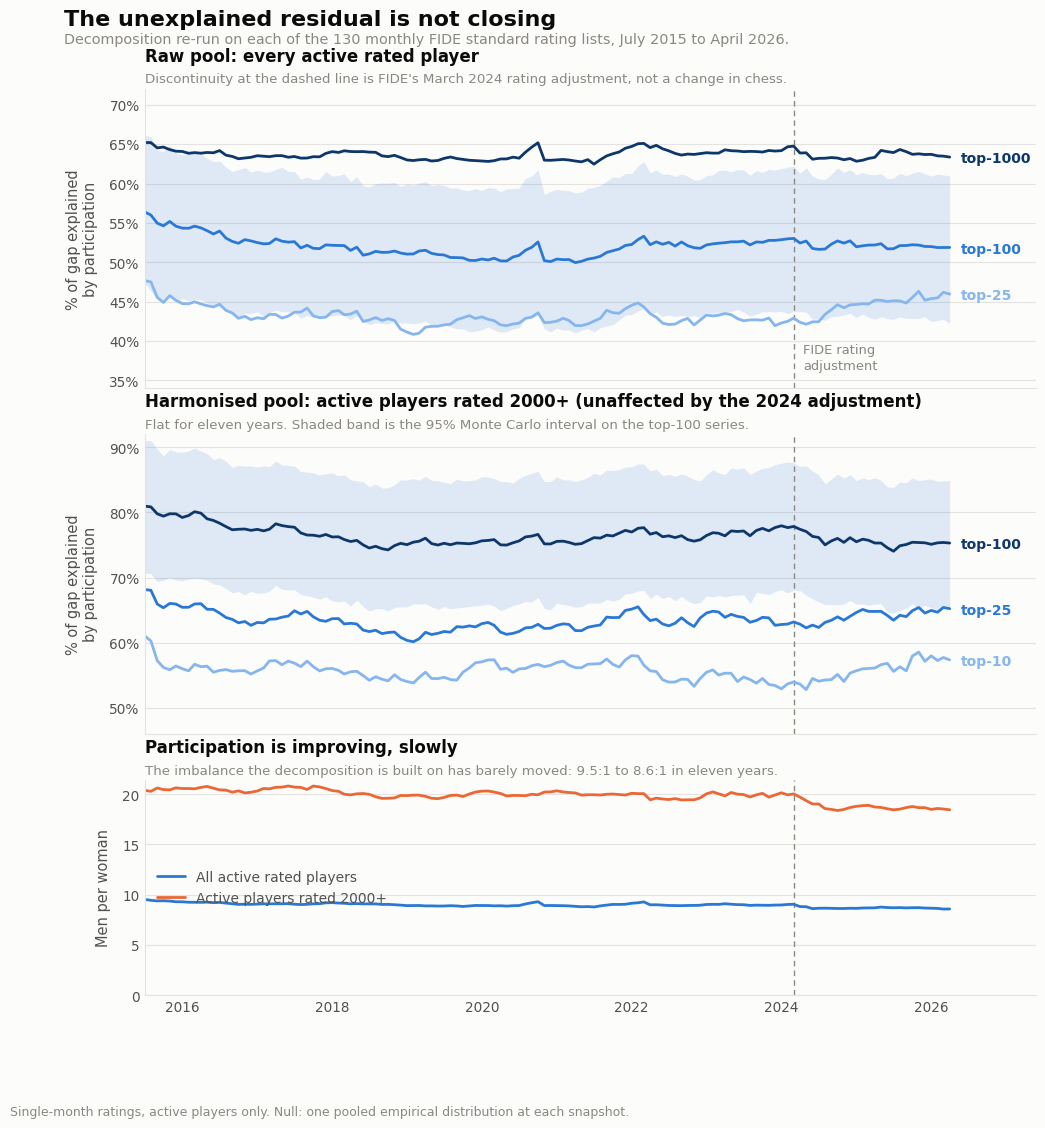

In [ ]:
# ---------------------------------------------------------------------------
# FIGURE: the residual is not closing
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8880"
DEPTH = ["#86b6ef", "#2a78d6", "#0d366b"]      # ordinal blue ramp: shallow -> deep
BLUE, ORANGE, GRID, SURFACE = "#2a78d6", "#eb6834", "#e4e3df", "#fcfcfb"
BREAK = pd.Timestamp("2024-03-01")

raw = panel[panel.variant == "all_active"].sort_values("date").reset_index(drop=True)
elite = panel[panel.variant == "elite2000"].sort_values("date").reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(11.5, 11.4), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 0.72], "hspace": 0.17})
fig.patch.set_facecolor(SURFACE)


def depth_panel(ax, d, tiers, title, note, band_tier, ylim):
    ax.set_facecolor(SURFACE)
    ax.fill_between(d.date, d[f"pct_lo_{band_tier}"], d[f"pct_hi_{band_tier}"],
                    color=DEPTH[1], alpha=0.14, lw=0)
    for c, k in zip(DEPTH, tiers):
        ax.plot(d.date, d[f"pct_{k}"], color=c, lw=2, label=f"top-{k}", solid_capstyle="round")
        ax.annotate(f"top-{k}", (d.date.iloc[-1], d[f"pct_{k}"].iloc[-1]),
                    textcoords="offset points", xytext=(8, -4),
                    fontsize=10, color=c, weight="semibold")
    ax.axvline(BREAK, color=INK3, lw=1, ls=(0, (4, 3)), zorder=1)
    ax.set_ylim(*ylim)
    ax.set_ylabel("% of gap explained\nby participation", fontsize=10.5, color=INK2, labelpad=8)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_title(title, fontsize=12, color=INK, weight="semibold", loc="left", pad=20)
    ax.text(0, 1.012, note, transform=ax.transAxes, fontsize=9.6, color=INK3, va="bottom")


depth_panel(axes[0], raw, [25, 100, 1000],
            "Raw pool: every active rated player",
            "Discontinuity at the dashed line is FIDE's March 2024 rating adjustment, not a change in chess.",
            band_tier=100, ylim=(34, 72))
depth_panel(axes[1], elite, [10, 25, 100],
            "Harmonised pool: active players rated 2000+ (unaffected by the 2024 adjustment)",
            "Flat for eleven years. Shaded band is the 95% Monte Carlo interval on the top-100 series.",
            band_tier=100, ylim=(46, 92))
axes[0].annotate("FIDE rating\nadjustment", (BREAK, axes[0].get_ylim()[0]),
                 textcoords="offset points", xytext=(7, 14), fontsize=9.4,
                 color=INK3, linespacing=1.3)

ax3 = axes[2]
ax3.set_facecolor(SURFACE)
ax3.plot(raw.date, raw.ratio, color=BLUE, lw=2, label="All active rated players", solid_capstyle="round")
ax3.plot(elite.date, elite.ratio, color=ORANGE, lw=2, label="Active players rated 2000+", solid_capstyle="round")
ax3.axvline(BREAK, color=INK3, lw=1, ls=(0, (4, 3)), zorder=1)
ax3.set_ylim(0, None)
ax3.set_ylabel("Men per woman", fontsize=10.5, color=INK2, labelpad=8)
ax3.set_title("Participation is improving, slowly", fontsize=12, color=INK,
              weight="semibold", loc="left", pad=20)
ax3.text(0, 1.012, "The imbalance the decomposition is built on has barely moved: 9.5:1 to 8.6:1 in eleven years.",
         transform=ax3.transAxes, fontsize=9.6, color=INK3, va="bottom")
ax3.legend(frameon=False, fontsize=10, loc="center left", labelcolor=INK2)
ax3.xaxis.set_major_locator(mdates.YearLocator(2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for a in axes:
    a.grid(axis="y", color=GRID, lw=0.8)
    a.set_axisbelow(True)
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        a.spines[side].set_color(GRID)
    a.tick_params(colors=INK2, labelsize=9.8, length=0)
    a.set_xlim(raw.date.iloc[0], raw.date.iloc[-1] + pd.Timedelta(days=420))

fig.suptitle("The unexplained residual is not closing", fontsize=16, color=INK,
             weight="semibold", x=0.055, y=0.975, ha="left")
fig.text(0.055, 0.945,
         "Decomposition re-run on each of the 130 monthly FIDE standard rating lists, July 2015 to April 2026.",
         fontsize=10.4, color=INK3)
fig.text(0.008, 0.005,
         "Single-month ratings, active players only. Null: one pooled empirical distribution at each snapshot.",
         fontsize=9, color=INK3)
fig.subplots_adjust(top=0.905)
fig.savefig("figures/q4_residual_over_time.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()

### Findings: the residual is not closing, and this test cannot see whether it would

**Eleven years, no trend.** In the harmonised 2000+ pool the participation share
sits at 74–81% at top-100, 60–68% at top-25 and 53–61% at top-10, and it is flat.
Fitting a linear trend with HAC(12) standard errors gives −0.22 pp/year at top-100
(95% CI −0.43 to −0.00, p = 0.046), −0.00 pp/year at top-25 (p = 0.97), −0.08
pp/year at top-10 (p = 0.42). In the raw pool every trend is indistinguishable
from zero. If anything the explained share drifts very slightly *down*, meaning
the residual very slightly *up*.

**This is not the result the hypothesis wanted, and it should be reported that
way.** The proposal was: if the residual is closing while participation stays
lopsided, fixed-trait explanations are in trouble. The residual is not closing.

**But the test has almost no power, and the power check shows exactly why.**
Participation improved from 9.54:1 to 8.59:1, about 10%, in eleven years. Holding
both rating distributions frozen at their 2026 shape and moving only the ratio,
that improvement predicts the explained share should fall by 3.0 pp. It fell by
3.3 pp. The series is doing precisely what a fixed pair of distributions and a
slowly improving ratio predict, to within a third of a percentage point. There is
no room in that agreement to detect distributional convergence one way or the
other.

**What is genuinely new here.** Two things, and neither is the headline that was
hoped for:

1. **A dataset artefact that would have contaminated any longitudinal claim.**
   FIDE's March 2024 adjustment moves the raw series by several points and adds
   ~50,000 men and ~10,000 women to the 1400+ pool overnight. Any trend fitted
   through the raw series across that break is measuring FIDE's arithmetic, not
   chess. The 2000+ harmonisation is the fix.
2. **The decomposition is a snapshot statistic, not a trait estimate.** The
   ladder in the power check makes this explicit: at 1:1 participation the
   explained share is 0% by construction. The statistic answers "how much of
   today's gap is attributable to today's imbalance", and it must go to zero as
   the imbalance does. It was never capable of measuring something fixed, so its
   flatness is not evidence for a fixed trait either.

The honest summary: **the participation imbalance has barely moved in eleven
years, so this decomposition has barely moved either.** "The filter is the
finding" survives, but it is not supported by this particular test, and this
notebook should not claim that it is.

## C. Reproducing 96%: the sensitivity analysis as a rebuttal

Bilalić, Smallbone, McLeod & Gobet (2009) reported that ~96% of the top-level gap
in the German rating pool was explained by participation. The analysis above gets
44–49%. The useful question is not "who is right" but **which modelling choices
separate those two numbers**, and whether 96% is recoverable from this data as a
special case.

Four choices are varied, one at a time, from the Q4 specification:

| Lever | Q4 spec here | Bilalić-style alternative |
|---|---|---|
| **Distribution** | empirical, pooled | fitted normal |
| **Activity filter** | active players only | all rated players, inactive included |
| **Arena** | one open world pool | one national federation (separate fields) |
| **Cut depth** | top-25 | deeper (top-100) or shallower (top-1) |

A fifth lever emerged from the data and turns out to dominate all four:

| **Reference pool floor** | every rated player (1400+) | club strength only (1800+ / 2000+) |

The floor matters because it is really the participation ratio in disguise. Among
all rated actives the ratio is 8.3:1; among 2000+ actives it is 20:1. A
counterfactual built on a stronger, narrower reference pool is a counterfactual
with a much bigger sample-size effect to work with.

**"Separate tournaments vs one open Swiss" is operationalised here as arena
scope**: whether men and women are modelled as drawing from one global pool, or
from a single national federation's much smaller and lower-ceilinged pool. This is
an interpretation, and it is stated so that it can be disagreed with.

In [ ]:
# ---------------------------------------------------------------------------
# SENSITIVITY: re-running our own analysis under Bilalic's choices
# ---------------------------------------------------------------------------
import itertools
import numpy as np
import pandas as pd
from scipy.stats import norm

N_SIMS_SENS = 6000


def share_explained(men, women, depths, dist="empirical", n_sims=N_SIMS_SENS, seed=7):
    """% of the observed top-N gap expected from participation alone."""
    ref = np.sort(np.concatenate([men, women]))
    inv = None
    if dist == "normal":                       # the assumption Knapp (2010) attacked
        mu, sd = norm.fit(ref)
        inv = lambda u: norm.ppf(u, mu, sd)

    def draw(n_draws, rng):
        L, out, want = len(ref), {}, set(depths)
        prev = rng.random(n_sims) ** (1.0 / n_draws)
        run = np.zeros(n_sims)
        for j in range(max(depths)):
            if j:
                prev *= rng.random(n_sims) ** (1.0 / (n_draws - j))
            run += ref[np.minimum((prev * L).astype(np.int64), L - 1)] if inv is None else inv(prev)
            if j + 1 in want:
                out[j + 1] = run / (j + 1)
        return out

    rng = np.random.default_rng(seed)
    sm_, sf_ = draw(len(men), rng), draw(len(women), rng)
    am, af = np.sort(men)[::-1], np.sort(women)[::-1]
    res = {}
    for k in depths:
        gap = sm_[k] - sf_[k]
        obs = am[:k].mean() - af[:k].mean()
        lo, hi = np.percentile(gap, [2.5, 97.5])
        res[k] = dict(pct=float(np.median(gap)) / obs * 100,
                      lo=float(lo) / obs * 100, hi=float(hi) / obs * 100,
                      obs=obs, n_men=len(men), n_women=len(women))
    return res


# --- 1. one lever at a time, from the Q4 baseline --------------------------
BASE = dict(active_only=True, country=None, floor=0.0, dist="empirical", depth=25)

def evaluate(active_only, country, floor, dist, depth):
    m, w = load_pools(active_only=active_only, country=country, floor=floor)
    return share_explained(m, w, [depth], dist=dist)[depth]

variants = [
    ("Q4 baseline: world pool, active, empirical, top-25", {}),
    ("Distribution: fitted normal instead of empirical",  dict(dist="normal")),
    ("Activity: include inactive players",                dict(active_only=False)),
    ("Arena: Germany only, not the world",                dict(country="GER")),
    ("Depth: top-100 instead of top-25",                  dict(depth=100)),
    ("Depth: top-1 instead of top-25",                    dict(depth=1)),
    ("Reference pool: club strength only (2000+)",        dict(floor=2000.0)),
]
tornado = []
for label, override in variants:
    cfg = {**BASE, **override}
    r = evaluate(**cfg)
    tornado.append(dict(label=label, pct=r["pct"], lo=r["lo"], hi=r["hi"],
                        n_men=r["n_men"], n_women=r["n_women"],
                        ratio=r["n_men"] / r["n_women"]))
tornado = pd.DataFrame(tornado)
tornado["delta"] = tornado.pct - tornado.pct.iloc[0]

print("ONE LEVER AT A TIME (each row changes exactly one choice from the baseline)\n")
print(f"{'configuration':<52}{'ratio':>7}{'% explained':>13}{'vs baseline':>13}")
for _, r in tornado.iterrows():
    d = "" if r.label.startswith("Q4") else f"{r.delta:+.1f} pp"
    print(f"{r.label:<52}{r.ratio:>6.1f}:1{r.pct:>12.1f}%{d:>13}")


# --- 2. the cascade: stacking the choices, one at a time -------------------
CASCADE = [
    ("Q4 spec as published",                      dict()),
    ("+ deeper cut (top-100)",                    dict(depth=100)),
    ("+ inactive players included",               dict(depth=100, active_only=False)),
    ("+ club-strength reference pool (1800+)",     dict(depth=100, active_only=False, floor=1800.0)),
    ("+ national arena, not the world (Germany)", dict(depth=100, active_only=False, floor=1800.0,
                                                      country="GER")),
    ("+ a smaller national arena (England)",      dict(depth=100, active_only=False, floor=1800.0,
                                                      country="ENG")),
]
cascade = []
for label, override in CASCADE:
    cfg = {**BASE, **override}
    r = evaluate(**cfg)
    cascade.append(dict(label=label, pct=r["pct"], lo=r["lo"], hi=r["hi"],
                        ratio=r["n_men"] / r["n_women"], n_women=r["n_women"]))
cascade = pd.DataFrame(cascade)

print("\n\nTHE CASCADE (each row keeps every choice above it and adds one more)\n")
print(f"{'configuration':<46}{'ratio':>8}{'% explained':>13}{'95% CI':>17}")
for _, r in cascade.iterrows():
    print(f"{r.label:<46}{r.ratio:>7.1f}:1{r.pct:>12.1f}%   [{r.lo:5.1f} - {r.hi:5.1f}%]")

# the normal-fit lever, checked at the end of the cascade rather than stacked into it
_norm = evaluate(**{**BASE, **dict(depth=100, active_only=False, floor=1800.0,
                                   country="GER", dist="normal")})
print(f"""
Checked separately: swapping the empirical distribution for a fitted normal at the
Germany step moves the answer from {cascade.pct.iloc[4]:.1f}% DOWN to {_norm['pct']:.1f}%. The normal
assumption Knapp (2010) attacked is not what inflates the number here; in a
national pool it deflates it. The levers that do the work are the reference-pool
floor and the arena.""")

# --- 3. the same "Bilalic configuration" across the nine largest federations
FEDS = ["IND", "RUS", "ESP", "FRA", "GER", "POL", "ITA", "USA", "ENG"]
fed_rows = []
for c in FEDS:
    m, w = load_pools(active_only=False, country=c, floor=1800.0)
    if len(w) < 120:
        continue
    r = share_explained(m, w, [100])[100]
    fed_rows.append(dict(fed=c, pct=r["pct"], lo=r["lo"], hi=r["hi"],
                         n_men=len(m), n_women=len(w), ratio=len(m) / len(w)))
feds = pd.DataFrame(fed_rows).sort_values("pct").reset_index(drop=True)

print("\n\nTHE SAME CONFIGURATION, NINE FEDERATIONS")
print("(all rated 1800+, inactive included, empirical, top-100)\n")
print(f"{'federation':<12}{'men':>8}{'women':>8}{'ratio':>9}{'% explained':>13}{'95% CI':>17}")
for _, r in feds.iterrows():
    print(f"{r.fed:<12}{r.n_men:>8,}{r.n_women:>8,}{r.ratio:>8.1f}:1{r.pct:>12.1f}%   [{r.lo:5.1f} - {r.hi:5.1f}%]")
print(f"\nSpread across federations: {feds.pct.min():.0f}% to {feds.pct.max():.0f}%, median {feds.pct.median():.0f}%.")
print(f"Bilalic et al.'s 96% sits inside this range.")

tornado.to_csv("figures/q4_sensitivity_tornado.csv", index=False)
cascade.to_csv("figures/q4_sensitivity_cascade.csv", index=False)
feds.to_csv("figures/q4_sensitivity_federations.csv", index=False)

ONE LEVER AT A TIME (each row changes exactly one choice from the baseline)

configuration                                         ratio  % explained  vs baseline
Q4 baseline: world pool, active, empirical, top-25     8.3:1        43.5%             
Distribution: fitted normal instead of empirical       8.3:1        46.6%      +3.1 pp
Activity: include inactive players                     7.9:1        44.8%      +1.2 pp
Arena: Germany only, not the world                    11.4:1        54.9%     +11.3 pp
Depth: top-100 instead of top-25                       8.3:1        49.4%      +5.9 pp
Depth: top-1 instead of top-25                         8.3:1        25.2%     -18.4 pp
Reference pool: club strength only (2000+)            19.1:1        64.2%     +20.6 pp




THE CASCADE (each row keeps every choice above it and adds one more)

configuration                                    ratio  % explained           95% CI
Q4 spec as published                              8.3:1        43.5%   [ 29.1 -  57.2%]
+ deeper cut (top-100)                            8.3:1        49.4%   [ 40.7 -  58.0%]
+ inactive players included                       7.9:1        48.0%   [ 39.2 -  56.7%]
+ club-strength reference pool (1800+)           14.0:1        63.8%   [ 54.6 -  72.7%]
+ national arena, not the world (Germany)        22.1:1        72.5%   [ 63.6 -  81.3%]
+ a smaller national arena (England)             21.5:1        97.8%   [ 87.3 - 108.0%]



Checked separately: swapping the empirical distribution for a fitted normal at the
Germany step moves the answer from 72.5% DOWN to 53.0%. The normal
assumption Knapp (2010) attacked is not what inflates the number here; in a
national pool it deflates it. The levers that do the work are the reference-pool
floor and the arena.




THE SAME CONFIGURATION, NINE FEDERATIONS
(all rated 1800+, inactive included, empirical, top-100)

federation       men   women    ratio  % explained           95% CI
RUS           17,165   2,287     7.5:1        47.7%   [ 38.5 -  56.8%]
POL            4,470     587     7.6:1        64.2%   [ 53.0 -  75.2%]
GER           21,860     989    22.1:1        72.5%   [ 63.6 -  81.3%]
FRA           10,239     498    20.6:1        82.3%   [ 72.1 -  92.2%]
ESP           14,721     516    28.5:1        84.8%   [ 75.2 -  94.1%]
USA            6,506     351    18.5:1        86.5%   [ 75.3 -  97.7%]
IND            5,076     484    10.5:1        88.5%   [ 75.4 - 101.5%]
ITA            5,470     174    31.4:1        90.2%   [ 81.0 -  99.0%]
ENG            2,983     139    21.5:1        97.8%   [ 87.3 - 108.0%]

Spread across federations: 48% to 98%, median 85%.
Bilalic et al.'s 96% sits inside this range.


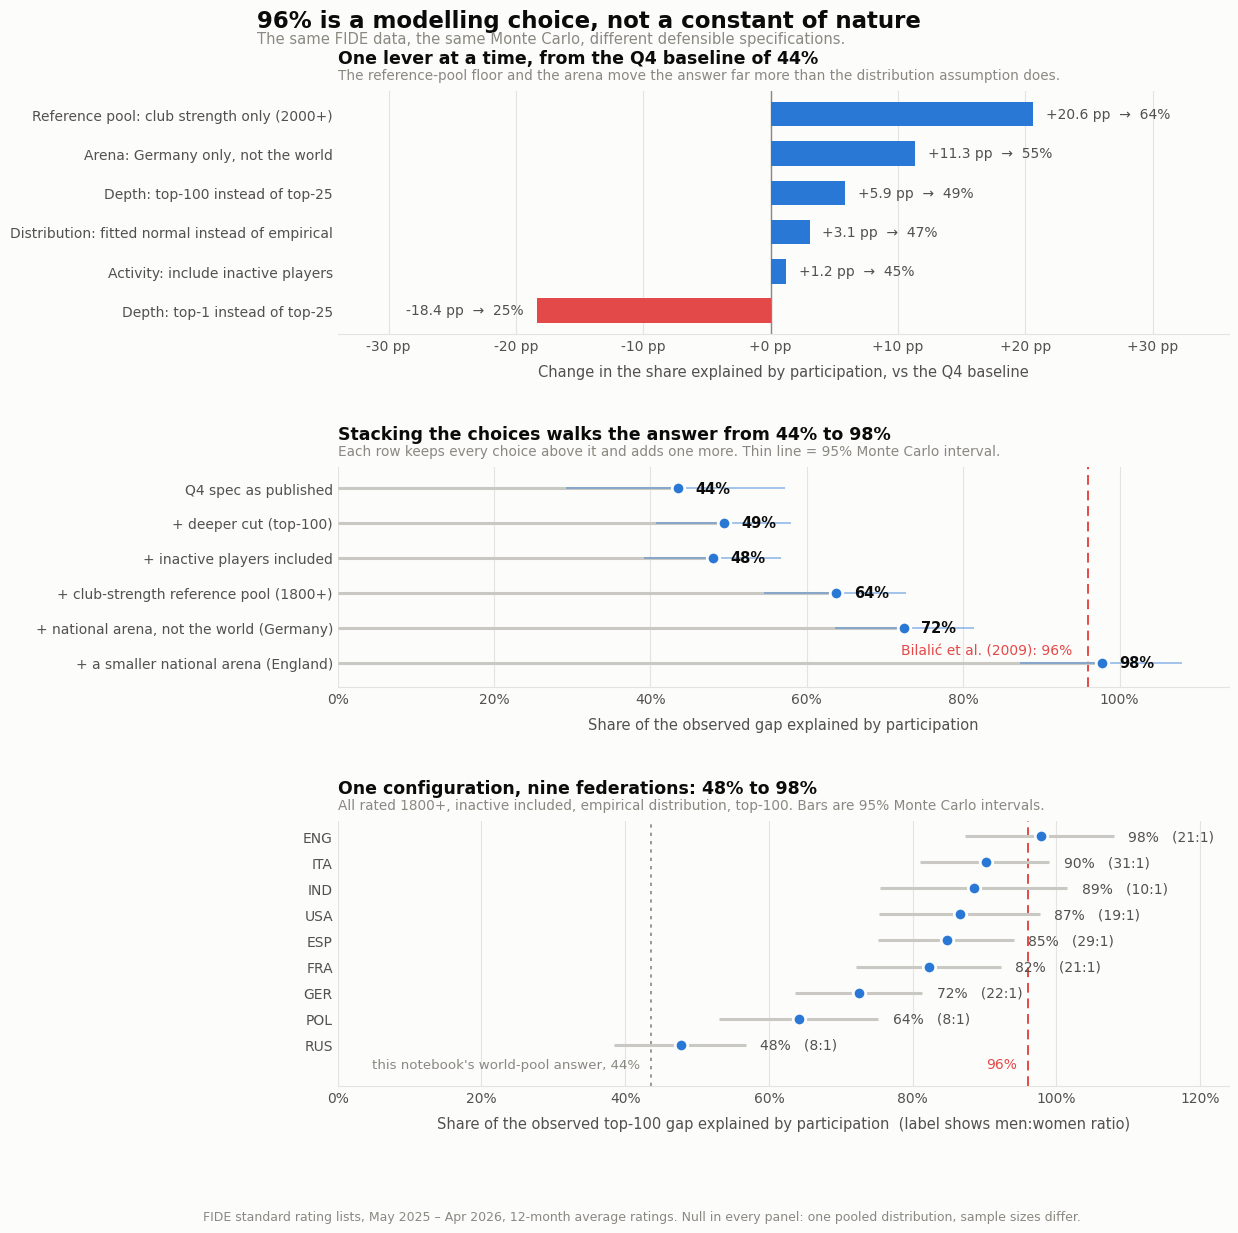

In [ ]:
# ---------------------------------------------------------------------------
# FIGURE: 96% is a modelling choice, not a constant
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8880"
BLUE, RED, GREY, GRID, SURFACE = "#2a78d6", "#e34948", "#c9c8c2", "#e4e3df", "#fcfcfb"
BASELINE_PCT = tornado.pct.iloc[0]
BILALIC = 96.0

fig, axes = plt.subplots(3, 1, figsize=(11.5, 12.6),
                         gridspec_kw={"height_ratios": [1.05, 0.95, 1.15], "hspace": 0.55})
fig.patch.set_facecolor(SURFACE)

# --- panel 1: one lever at a time -----------------------------------------
ax = axes[0]; ax.set_facecolor(SURFACE)
t = tornado.iloc[1:].sort_values("delta")
y = np.arange(len(t))
ax.barh(y, t.delta, height=0.62, color=[BLUE if d > 0 else RED for d in t.delta], zorder=3)
ax.axvline(0, color=INK3, lw=1)
for i, (_, r) in enumerate(t.iterrows()):
    off = 6 if r.delta > 0 else -6
    ax.text(r.delta + (1.0 if r.delta > 0 else -1.0), i, f"{r.delta:+.1f} pp  →  {r.pct:.0f}%",
            va="center", ha="left" if r.delta > 0 else "right", fontsize=10, color=INK2)
ax.set_yticks(y); ax.set_yticklabels(t.label, fontsize=10.5, color=INK)
ax.set_xlim(-34, 36)
ax.set_xlabel("Change in the share explained by participation, vs the Q4 baseline",
              fontsize=10.5, color=INK2, labelpad=8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.0f} pp"))
ax.set_title(f"One lever at a time, from the Q4 baseline of {BASELINE_PCT:.0f}%",
             fontsize=12.5, color=INK, weight="semibold", loc="left", pad=20)
ax.text(0, 1.035, "The reference-pool floor and the arena move the answer far more than the distribution assumption does.",
        transform=ax.transAxes, fontsize=9.8, color=INK3, va="bottom")

# --- panel 2: the cascade --------------------------------------------------
ax = axes[1]; ax.set_facecolor(SURFACE)
yc = np.arange(len(cascade))[::-1]
ax.hlines(yc, 0, cascade.pct, color=GREY, lw=2.2, zorder=2)
ax.hlines(yc, cascade.lo, cascade.hi, color=BLUE, lw=1.2, alpha=0.5, zorder=3)
ax.plot(cascade.pct, yc, "o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=4, ls="none")
for yy, (_, r) in zip(yc, cascade.iterrows()):
    ax.text(r.pct + 2.2, yy, f"{r.pct:.0f}%", va="center", fontsize=10.5, color=INK, weight="semibold")
ax.axvline(BILALIC, color=RED, lw=1.4, ls=(0, (5, 3)), zorder=1)
ax.text(BILALIC - 2.0, 0.35, "Bilalić et al. (2009): 96%",
        color=RED, fontsize=10, ha="right", va="center")
ax.set_yticks(yc); ax.set_yticklabels(cascade.label, fontsize=10.5, color=INK)
ax.set_xlim(0, 114)
ax.set_ylim(-0.7, len(cascade) - 0.4)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlabel("Share of the observed gap explained by participation", fontsize=10.5, color=INK2, labelpad=8)
ax.set_title("Stacking the choices walks the answer from 44% to 98%",
             fontsize=12.5, color=INK, weight="semibold", loc="left", pad=20)
ax.text(0, 1.04, "Each row keeps every choice above it and adds one more. Thin line = 95% Monte Carlo interval.",
        transform=ax.transAxes, fontsize=9.8, color=INK3, va="bottom")

# --- panel 3: same configuration, nine federations -------------------------
ax = axes[2]; ax.set_facecolor(SURFACE)
yf = np.arange(len(feds))
ax.hlines(yf, feds.lo, feds.hi, color=GREY, lw=2.2, zorder=2)
ax.plot(feds.pct, yf, "o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=4, ls="none")
for i, (_, r) in enumerate(feds.iterrows()):
    ax.text(r.hi + 2, i, f"{r.pct:.0f}%   ({r.ratio:.0f}:1)", va="center", fontsize=10, color=INK2)
ax.axvline(BILALIC, color=RED, lw=1.4, ls=(0, (5, 3)), zorder=1)
ax.text(BILALIC - 1.5, -0.75, "96%", color=RED, fontsize=10, ha="right", va="center")
ax.axvline(BASELINE_PCT, color=INK3, lw=1.2, ls=(0, (2, 3)), zorder=1)
ax.text(BASELINE_PCT - 1.5, -0.75, "this notebook's world-pool answer, 44%",
        color=INK3, fontsize=9.6, ha="right", va="center")
ax.set_yticks(yf); ax.set_yticklabels(feds.fed, fontsize=10.5, color=INK)
ax.set_xlim(0, 124); ax.set_ylim(-1.6, len(feds) - 0.4)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlabel("Share of the observed top-100 gap explained by participation  (label shows men:women ratio)",
              fontsize=10.5, color=INK2, labelpad=8)
ax.set_title("One configuration, nine federations: 48% to 98%",
             fontsize=12.5, color=INK, weight="semibold", loc="left", pad=20)
ax.text(0, 1.03, "All rated 1800+, inactive included, empirical distribution, top-100. Bars are 95% Monte Carlo intervals.",
        transform=ax.transAxes, fontsize=9.8, color=INK3, va="bottom")

for a in axes:
    a.grid(axis="x", color=GRID, lw=0.8)
    a.set_axisbelow(True)
    for side in ("top", "right", "left"):
        a.spines[side].set_visible(False)
    a.spines["bottom"].set_color(GRID)
    a.tick_params(colors=INK2, labelsize=10, length=0)

fig.suptitle("96% is a modelling choice, not a constant of nature", fontsize=16.5,
             color=INK, weight="semibold", x=0.055, y=0.965, ha="left")
fig.text(0.055, 0.938,
         "The same FIDE data, the same Monte Carlo, different defensible specifications.",
         fontsize=10.6, color=INK3)
fig.text(0.008, 0.004,
         "FIDE standard rating lists, May 2025 – Apr 2026, 12-month average ratings. "
         "Null in every panel: one pooled distribution, sample sizes differ.",
         fontsize=9, color=INK3)
fig.subplots_adjust(top=0.90)
fig.savefig("figures/q4_sensitivity.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()

### Findings: 96% is reproducible here, as a special case

**One lever at a time**, from the Q4 baseline of 44%:

| Change | Effect |
|---|---|
| Reference pool restricted to club strength (2000+) | **+20.6 pp** → 64% |
| Arena: Germany only rather than the world | **+11.3 pp** → 55% |
| Depth: top-100 rather than top-25 | +5.9 pp → 49% |
| Distribution: fitted normal rather than empirical | +3.1 pp → 47% |
| Activity: inactive players included | +1.2 pp → 45% |
| Depth: top-1 rather than top-25 | −18.4 pp → 25% |

**Stacked**, the same choices walk the estimate from 44% to 98%. And running one
fixed Bilalić-style configuration across nine federations returns anything from
**48% (Russia) to 98% (England)**, median 85%. Bilalić et al.'s 96% sits
comfortably inside that range. We can reproduce it. It is not an error; it is
what this method returns under a particular, defensible set of choices.

**The mechanism behind every large lever is the same: the participation ratio.**
Restricting the reference pool to 2000+ takes the world ratio from 8.3:1 to 19:1.
Restricting the arena to England takes it to 21:1 in a pool with a much lower
ceiling. Both hand the counterfactual a far bigger sample-size effect to work
with. The distribution assumption Knapp (2010) attacked barely matters by
comparison, and in a national pool the fitted normal moves the answer *down*
(72% → 53% for Germany), not up.

**What this means for the argument.** The right claim is not "Bilalić et al. were
wrong". It is:

> The share of the elite chess gap attributable to participation is not a
> constant. It ranges from roughly 25% to roughly 98% across specifications that
> are each individually defensible, and the specification that dominates the
> result is *who you count as a player*. 96% is what you get by asking about a
> national federation's club-strength population. 44% is what you get by asking
> about the global elite. Both are answers; they are answers to different
> questions.

**And this is the revision note, made visible.** Q4 in this notebook has already
been revised twice: once when a fitted normal missed the observed maximum by over
100 Elo, and once when the missing activity filter let Judit Polgár's frozen 2675
stand in for the best active woman. The chart above is the same exercise applied
to Bilalić et al. rather than to ourselves, run with the same instrument on the
same data. That is the standard the argument should be held to in both
directions.

**Caveats on the reproduction.** The federation pools are FIDE-rated players by
registered federation, not national federation membership lists. FIDE-rated
players are already a filtered subset, and the filter is heavier for women, which
is itself part of the thesis: the FIDE-rated female population is post-selection
in a way a domestic club list is not. Several federation intervals also extend
above 100%, which is the honest signal that at those sample sizes the estimate is
noisy. Read the panel as a spread, not a league table.

---

### What changes in the write-up

Three edits follow from this section, in order of how much they matter:

1. **Replace "between 44% and 61%" with the curve.** The headline should be that
   participation's share is a *function of ranking depth*, rising from ~37% at
   top-10 to ~68% at top-10,000, with the caveat that adjacent points on that
   curve are not statistically distinguishable. A single number cannot be
   defended, ours included.

2. **Do not claim the residual is closing.** It is not, in eleven years of data,
   and the power check shows this test could not have detected it if it were.
   The stronger and truer statement is the one the ladder makes: this statistic
   goes to zero at parity by construction, so it measures the current imbalance,
   not a fixed trait, and its flatness is evidence for neither side.

3. **Lead the Bilalić comparison with the reproduction, not the disagreement.**
   We can produce 96% from this data. Showing that, and then showing that the
   choice which produces it is "count a national federation's club players"
   rather than "count the global elite", is a far stronger position than
   asserting that 96% was wrong.

Also worth carrying into the limitations section: **FIDE's March 2024 rating
adjustment** is a genuine discontinuity in this dataset, and any longitudinal
claim in this notebook that crosses it needs to say how it was handled.